Title: LEE_Results_Analysis_GEV_GPD_fits.ipynb

Purpose: Make some GEV and GPD fits for the VRES events

Author: Onno Nennecke on 16.07.2025 Modified: 20.04.2026

Input data: 

- LEE Tables: LEE_dat_14.csv, LEE_dat_7.csv, LEE_dat.csv, LEE_dat_14_selection.csv, LEE_dat_7_selection.csv, LEE_vl.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

- LEE Tables: LEE_dat_14_fut.csv, LEE_dat_7_fut.csv, LEE_dat_fut.csv, LEE_dat_14_selection_fut.csv, LEE_dat_7_selection_fut.csv, LEE_vl_fut.csv
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

Output data:



In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

import seaborn as sns

from scipy import stats
from scipy.stats import genextreme, genpareto, ks_2samp, norm


In [2]:
# Function to add a winter season column
def add_winter_season_column(df):
    # Ensure 'date_start' is in datetime format
    df['date_start'] = pd.to_datetime(df['date_start'])
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    
    # Apply the function to create a new 'winter_season' column
    df['winter_season'] = df['date_start'].apply(get_winter_season)
    
    df['season_year'] = df['winter_season'].apply(lambda x: int(x.split('/')[0])) + 2000
    
    return df

### Read LEE data

In [3]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')
LEE_dat = add_winter_season_column(LEE_dat)

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')
LEE_7 = add_winter_season_column(LEE_7)

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')
LEE_14 = add_winter_season_column(LEE_14)

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')
LEE_vl = add_winter_season_column(LEE_vl)

# Read the LEE data
LEE_dat_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_fut.csv')
LEE_dat_fut = add_winter_season_column(LEE_dat_fut)

LEE_dat_7_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_fut.csv')
LEE_7_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_fut.csv')
LEE_7_fut = add_winter_season_column(LEE_7_fut)

LEE_dat_14_all_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_fut.csv')
LEE_14_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_fut.csv')
LEE_14_fut = add_winter_season_column(LEE_14_fut)

LEE_vl_fut = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_fut.csv')
LEE_vl_fut = add_winter_season_column(LEE_vl_fut)


LEE_dat_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_ERA5_1960_.csv')
LEE_dat_ERA5_1960_ = add_winter_season_column(LEE_dat_ERA5_1960_)
LEE_dat_7_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection_ERA5_1960_.csv')
LEE_dat_7_ERA5_1960_ = add_winter_season_column(LEE_dat_7_ERA5_1960_)
LEE_dat_14_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection_ERA5_1960_.csv')
LEE_dat_14_ERA5_1960_ = add_winter_season_column(LEE_dat_14_ERA5_1960_)
LEE_vl_ERA5_1960_ = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl_ERA5_1960_.csv')
LEE_vl_ERA5_1960_ = add_winter_season_column(LEE_vl_ERA5_1960_)


# ERA5 data
LEE_dat_ERA5_15_24 = LEE_dat[LEE_dat['ESM'] == 'ERA5_week']
LEE_7_ERA5_15_24 = LEE_7[LEE_7['ESM'] == 'ERA5_week']
LEE_14_ERA5_15_24 = LEE_14[LEE_14['ESM'] == 'ERA5_week']
LEE_vl_ERA5_15_24 = LEE_vl[LEE_vl['ESM'] == 'ERA5_week']

In [4]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd') & (LEE_dat['ESM'] != 'ERA5_week')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd') & (LEE_7['ESM'] != 'ERA5_week')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd') & (LEE_14['ESM'] != 'ERA5_week')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd') & (LEE_vl['ESM'] != 'ERA5_week')]

In [5]:
# Pure CMIP6 data
LEE_dat_CMIP = LEE_dat[LEE_dat['ESM'] != 'ERA5_week']
LEE_7_CMIP = LEE_7[LEE_7['ESM'] != 'ERA5_week']
LEE_14_CMIP = LEE_14[LEE_14['ESM'] != 'ERA5_week']
LEE_vl_CMIP = LEE_vl[LEE_vl['ESM'] != 'ERA5_week']

In [6]:
# Pure ERA5 data
# LEE_dat_ERA5 = LEE_dat[(LEE_dat['ESM'] == 'ERA5_week')]
# LEE_7_ERA5 = LEE_7[(LEE_7['ESM'] == 'ERA5_week')]
# LEE_14_ERA5 = LEE_14[(LEE_14['ESM'] == 'ERA5_week')]
# LEE_vl_ERA5 = LEE_vl[(LEE_vl['ESM'] == 'ERA5_week')]
LEE_dat_ERA5 = LEE_dat_ERA5_1960_
LEE_7_ERA5 = LEE_dat_7_ERA5_1960_
LEE_14_ERA5 = LEE_dat_14_ERA5_1960_
LEE_vl_ERA5 = LEE_vl_ERA5_1960_


In [7]:
LEE_dat_ERA5_1960_

LEE_dat_ERA5_1960_1990 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] < '1990-01-01']
LEE_dat_ERA5_1990_2024 = LEE_dat_ERA5_1960_[LEE_dat_ERA5_1960_['date_start'] >= '1990-01-01']

In [8]:
# Function to add a winter season coordinate to an xarray Dataset
def add_winter_season_coordinate(ds, time_dim='time'):
    # Ensure the time coordinate is in datetime format
    time_values = pd.to_datetime(ds[time_dim].values)
    
    # Define a function to determine the winter season for each date
    def get_winter_season(date):
        year = date.year
        if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
            return f"{year-2000}/{year-2000+1}"
        else:  # January, February, March, April, May, June belong to the current year's winter
            return f"{year-2000-1}/{year-2000}"
    # def get_winter_season(date):
    #     year = date.year
    #     if date.month >= 7:  # July, August, September, October, November, December belong to the next year's winter
    #         return year
    #     else:  # January, February, March, April, May, June belong to the current year's winter
    #         return year-1
    # Apply the function to create a new array of winter seasons
    winter_seasons = np.array([get_winter_season(date) for date in time_values])

    # Add the new coordinate to the Dataset
    ds = ds.assign_coords(winter_season=(time_dim, winter_seasons))
    return ds

In [9]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all_future.nc'
files = [path]

ds = xr.open_dataset(path)

ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()


ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

res_load_fut = ts_datasets['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_fut_1d = res_load_fut.values.ravel()

res_load_fut_7d = res_load_fut.rolling(time=7, center=False).mean()
res_load_fut_14d = res_load_fut.rolling(time=14, center=False).mean()


In [10]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)
ds = add_winter_season_coordinate(ds, time_dim='time')

ts_datasets_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ts_datasets_ERA5.load()
res_load_era5_15_24 = ts_datasets_ERA5['Residual_load']
res_load_era5_15_24_1d = res_load_era5_15_24.values.ravel()

res_load_era5_15_24_7d = res_load_era5_15_24.rolling(time=7, center=False).mean()
res_load_era5_15_24_14d = res_load_era5_15_24.rolling(time=14, center=False).mean()

ts_datasets_curr_clim = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist') & (ds.ESM_run != 'ERA5_hist_week'),drop=True)
ts_datasets_curr_clim.load()

res_load_curr_clim = ts_datasets_curr_clim['Residual_load']
# Unravel the arrays to 1D for easier handling
res_load_curr_clim_1d = res_load_curr_clim.values.ravel()

res_load_curr_clim_7d = res_load_curr_clim.rolling(time=7, center=False).mean()
res_load_curr_clim_14d = res_load_curr_clim.rolling(time=14, center=False).mean()


In [11]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/full_year/ERA5_all_years/ERA5_hist_timeseries.nc'

ts_datasets_ERA5 = xr.open_dataset(path)
ts_datasets_ERA5 = add_winter_season_coordinate(ts_datasets_ERA5, time_dim='time')
ts_datasets_ERA5.load()
res_load_ERA5 = ts_datasets_ERA5['Residual_load']

res_load_ERA5_7d = res_load_ERA5.rolling(time=7, center=False).mean()
res_load_ERA5_14d = res_load_ERA5.rolling(time=14, center=False).mean()

In [12]:
# res_load_ERA5_1960_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
# res_load_ERA5_1990_2014 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year <= 2014), drop=True)['Residual_load']

# res_load_ERA5_1960_1970 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1960) & (ts_datasets_ERA5.time.dt.year < 1970), drop=True)['Residual_load']
# res_load_ERA5_1970_1980 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1970) & (ts_datasets_ERA5.time.dt.year < 1980), drop=True)['Residual_load']
# res_load_ERA5_1980_1990 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1980) & (ts_datasets_ERA5.time.dt.year < 1990), drop=True)['Residual_load']
# res_load_ERA5_1990_2000 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 1990) & (ts_datasets_ERA5.time.dt.year < 2000), drop=True)['Residual_load']
# res_load_ERA5_2000_2010 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2000) & (ts_datasets_ERA5.time.dt.year < 2010), drop=True)['Residual_load']
# res_load_ERA5_2010_2020 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2010) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']
# res_load_ERA5_2020_2024 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2020) & (ts_datasets_ERA5.time.dt.year <= 2024), drop=True)['Residual_load']

# res_load_ERA5_2015_2019 = ts_datasets_ERA5.where((ts_datasets_ERA5.time.dt.year >= 2015) & (ts_datasets_ERA5.time.dt.year < 2020), drop=True)['Residual_load']

# GPD

In [13]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
})

In [14]:
threshold = np.float64(1319.138650687668)

excesses_LEE = LEE_dat['RL_mean'] - threshold
excesses_LEE7 = LEE_7['RL_mean'] - threshold
excesses_LEE14 = LEE_14['RL_mean'] - threshold

excesses_LEE_fut = LEE_dat_fut['RL_mean'] - threshold
excesses_LEE7_fut = LEE_7_fut['RL_mean'] - threshold
excesses_LEE14_fut = LEE_14_fut['RL_mean'] - threshold

excesses_LEE_era = LEE_dat_ERA5['RL_mean'] - threshold
excesses_LEE7_era = LEE_7_ERA5['RL_mean'] - threshold
excesses_LEE14_era = LEE_14_ERA5['RL_mean'] - threshold

excesses_LEE_era5_15_24 = LEE_dat_ERA5_15_24['RL_mean'] - threshold
excesses_LEE7_era5_15_24 = LEE_7_ERA5_15_24['RL_mean'] - threshold
excesses_LEE14_era5_15_24 = LEE_14_ERA5_15_24['RL_mean'] - threshold
excesses = [excesses_LEE, excesses_LEE7, excesses_LEE14, 
            excesses_LEE_fut, excesses_LEE7_fut, excesses_LEE14_fut, 
            excesses_LEE_era, excesses_LEE7_era, excesses_LEE14_era,
            excesses_LEE_era5_15_24, excesses_LEE7_era5_15_24, excesses_LEE14_era5_15_24]
labels = ['LEE', 'LEE7', 'LEE14', 
          'LEE_fut', 'LEE7_fut', 'LEE14_fut', 
          'LEE_era', 'LEE7_era', 'LEE14_era', 
          'LEE_era5_15_24', 'LEE7_era5_15_24', 'LEE14_era5_15_24']


In [15]:
def GPD_fit(excesses, threshold, label):
    
    # Fit GPD to excesses    
    shape, loc, scale = genpareto.fit(excesses, floc=0)
    
    # print("shape (xi):", shape)
    # print("scale (sigma):", scale)
    
    
    # parameters
    u = threshold
    xi = shape
    sigma = scale

    # event rate
    if ('ERA5' in label) and ('15' in label):
        n_years = 10  # ERA5 covers 2015-2024 for this subset
    elif 'ERA5' in label:
        n_years = 65  # ERA5 covers 1960-2024
    else:
        n_years = 10 * 192  # 10 years for each of the 192 runs
    lambda_ = len(excesses) / n_years

    # return periods
    T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

    # return levels
    z_T = u + (sigma / xi) * ((lambda_ * T)**xi - 1)

    # Exceedance probability for return levels
    p_T = 1 - (1 + xi * (z_T - u) / sigma)**(-1/xi)

    return z_T

In [16]:
GPD_fit(excesses[0], threshold, labels)

array([1463.89564343, 1473.35049416, 1481.45908252, 1503.56355395,
       1517.09120733, 1528.37147329, 1540.4598955 , 1547.85785504,
       1554.02677059, 1560.63764803, 1564.68342034, 1566.73084271,
       1568.05705703])

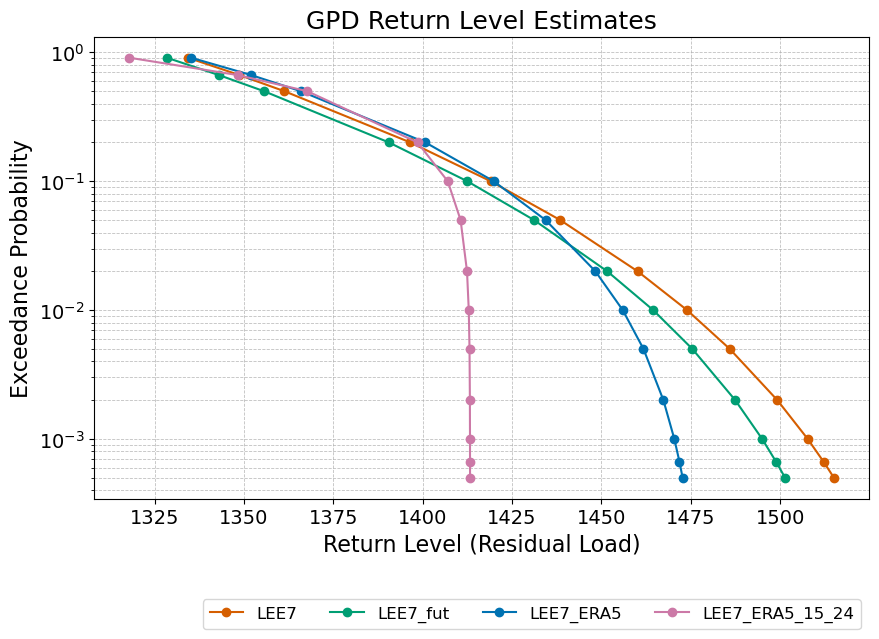

In [17]:
excesses = [excesses_LEE7, excesses_LEE7_fut, excesses_LEE7_era, excesses_LEE7_era5_15_24]
labels = ['LEE7', 'LEE7_fut', 'LEE7_ERA5', 'LEE7_ERA5_15_24']

z_T_list = []
for exc, label in zip(excesses, labels):
    # print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)    
    z_T_list.append(z_T)
colors = [
    "#D55E00",  # vermillion
    "#009E73",  # bluish green
    "#0072B2",  # blue
    "#CC79A7",  # reddish purple
    # "#E69F00",  # orange
]
# # Plot return levels
# plt.figure(figsize=(10, 6))
# T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
# for z_T, label in zip(z_T_list, labels):
#     plt.plot(T, z_T, marker='o', label=label)
# plt.xscale('log')
# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level (Residual Load)')
# plt.title('GPD Return Level Estimates')
# plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
# plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
# plt.show()

# # Plot return levels
# plt.figure(figsize=(10, 6))
# T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
# for z_T, label in zip(z_T_list, labels):
#     plt.plot(z_T, T, marker='o', label=label)
# plt.yscale('log')
# plt.ylabel('Return Period (years)')
# plt.xlabel('Return Level (Residual Load)')
# plt.title('GPD Return Level Estimates')
# plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
# plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
# plt.show()

T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])
exceedance_prob = 1 / T  # convert return period to exceedance probability

# Plot 1: exceedance prob on x-axis
# plt.figure(figsize=(10, 6))
# for z_T, label in zip(z_T_list, labels):
#     plt.plot(exceedance_prob, z_T, marker='o', label=label)
# plt.xscale('log')
# plt.gca().invert_xaxis()  # rare events (small prob) on the right
# plt.xlabel('Exceedance Probability')
# plt.ylabel('Return Level (Residual Load)')
# plt.title('GPD Return Level Estimates')
# plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
# plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
# plt.show()

# Plot 2: exceedance prob on y-axis
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    plt.plot(z_T, exceedance_prob, marker='o', label=label, color=colors[labels.index(label)])
plt.yscale('log')
# plt.gca().invert_yaxis()  # rare events (small prob) at the bottom
plt.ylabel('Exceedance Probability')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
plt.show()


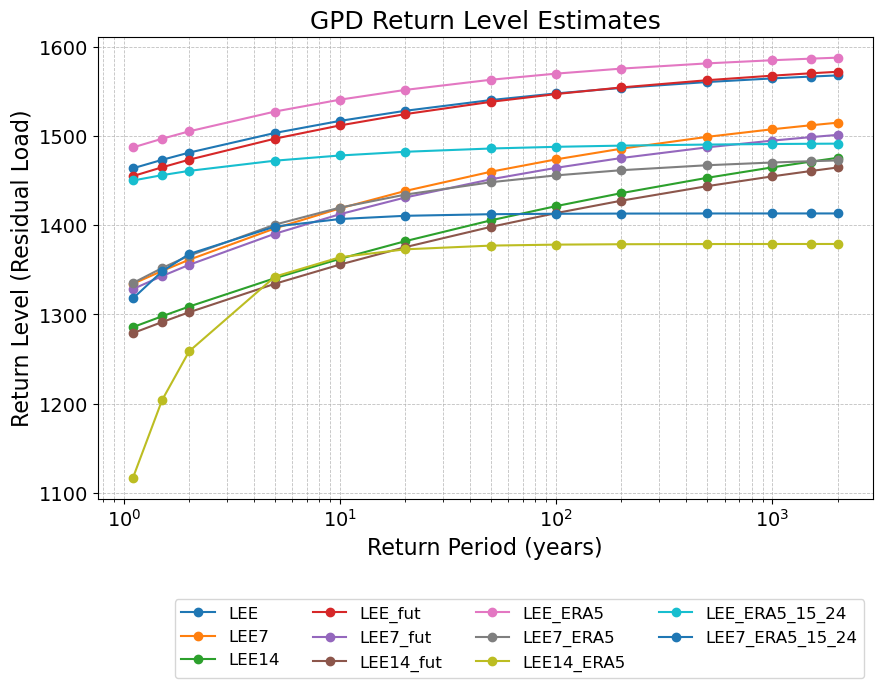

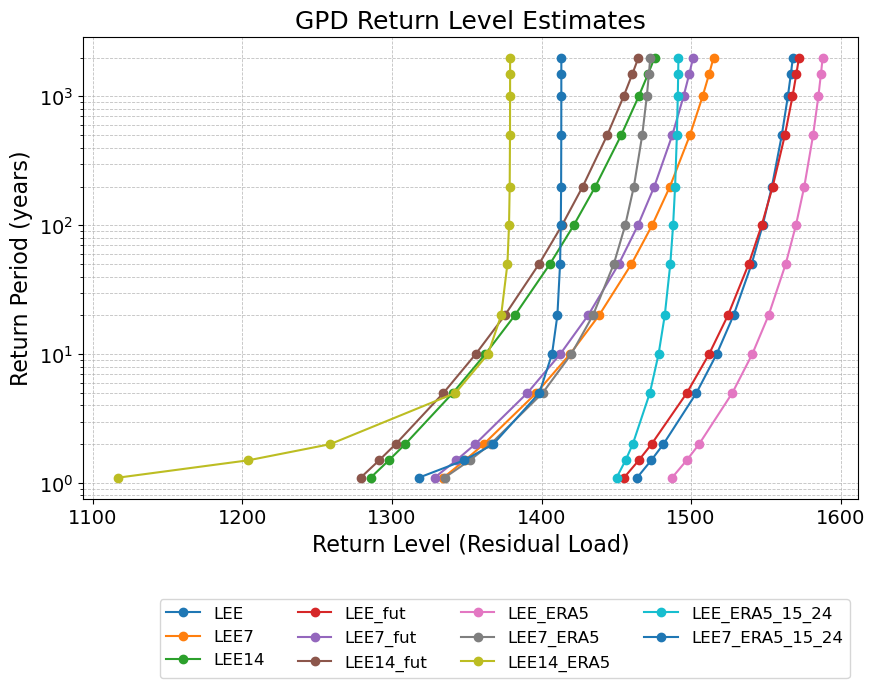

In [18]:
excesses = [excesses_LEE, excesses_LEE7, excesses_LEE14, 
            excesses_LEE_fut, excesses_LEE7_fut, excesses_LEE14_fut, 
            excesses_LEE_era, excesses_LEE7_era, excesses_LEE14_era,
            excesses_LEE_era5_15_24, excesses_LEE7_era5_15_24
            ]
labels = ['LEE', 'LEE7', 'LEE14', 
          'LEE_fut', 'LEE7_fut', 'LEE14_fut', 
          'LEE_ERA5', 'LEE7_ERA5', 'LEE14_ERA5',
          'LEE_ERA5_15_24', 'LEE7_ERA5_15_24'
          ]

z_T_list = []
for exc, label in zip(excesses, labels):
    # print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
plt.show()

# Plot return levels
plt.figure(figsize=(10, 6))
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
for z_T, label in zip(z_T_list, labels):
    plt.plot(z_T, T, marker='o', label=label)
plt.yscale('log')
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1, -0.2), ncols=4, fontsize=12)
plt.show()

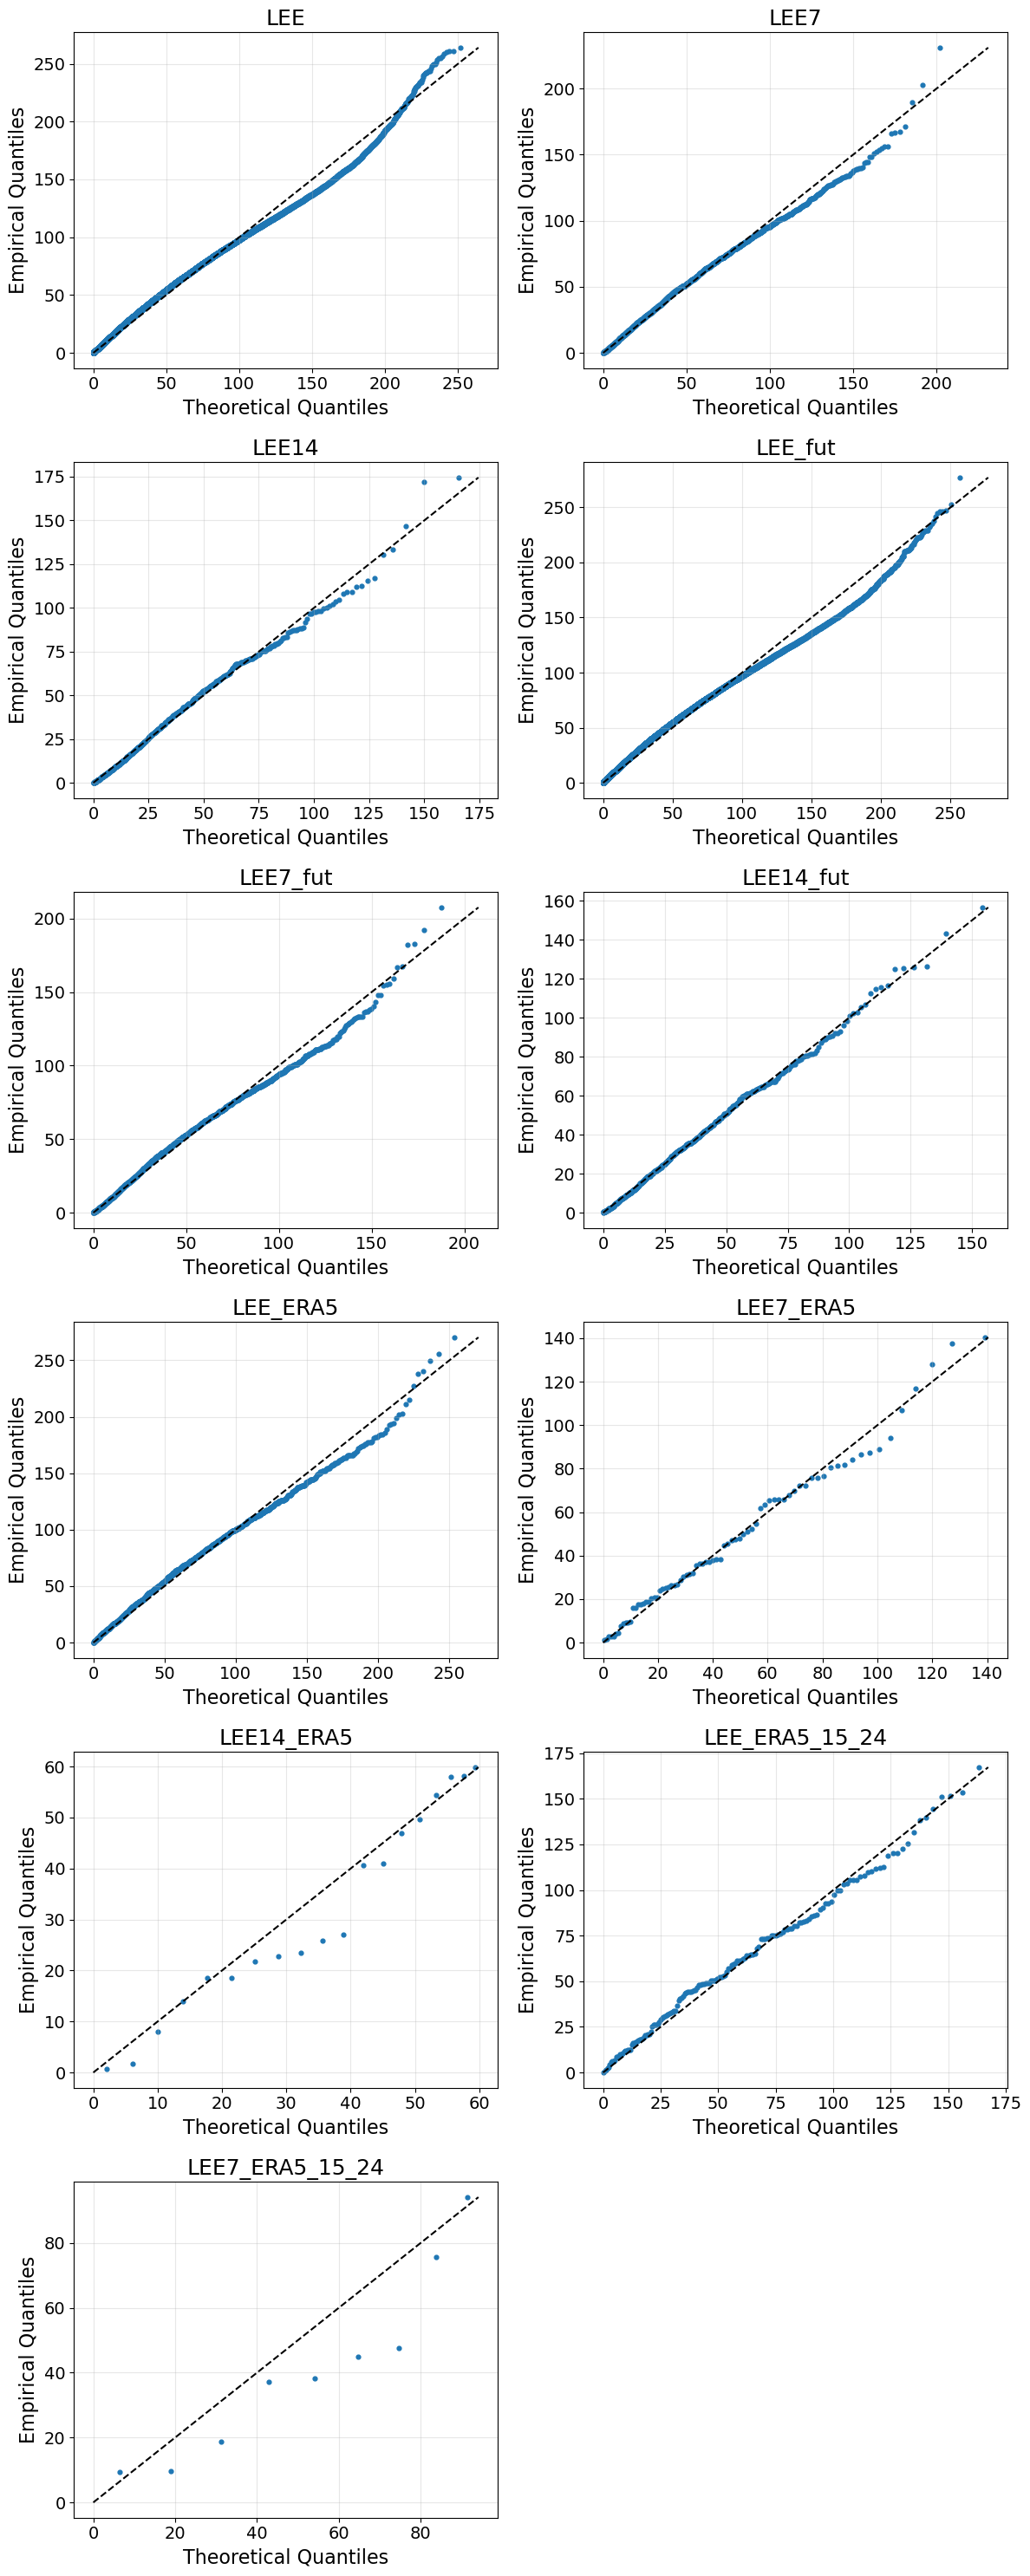

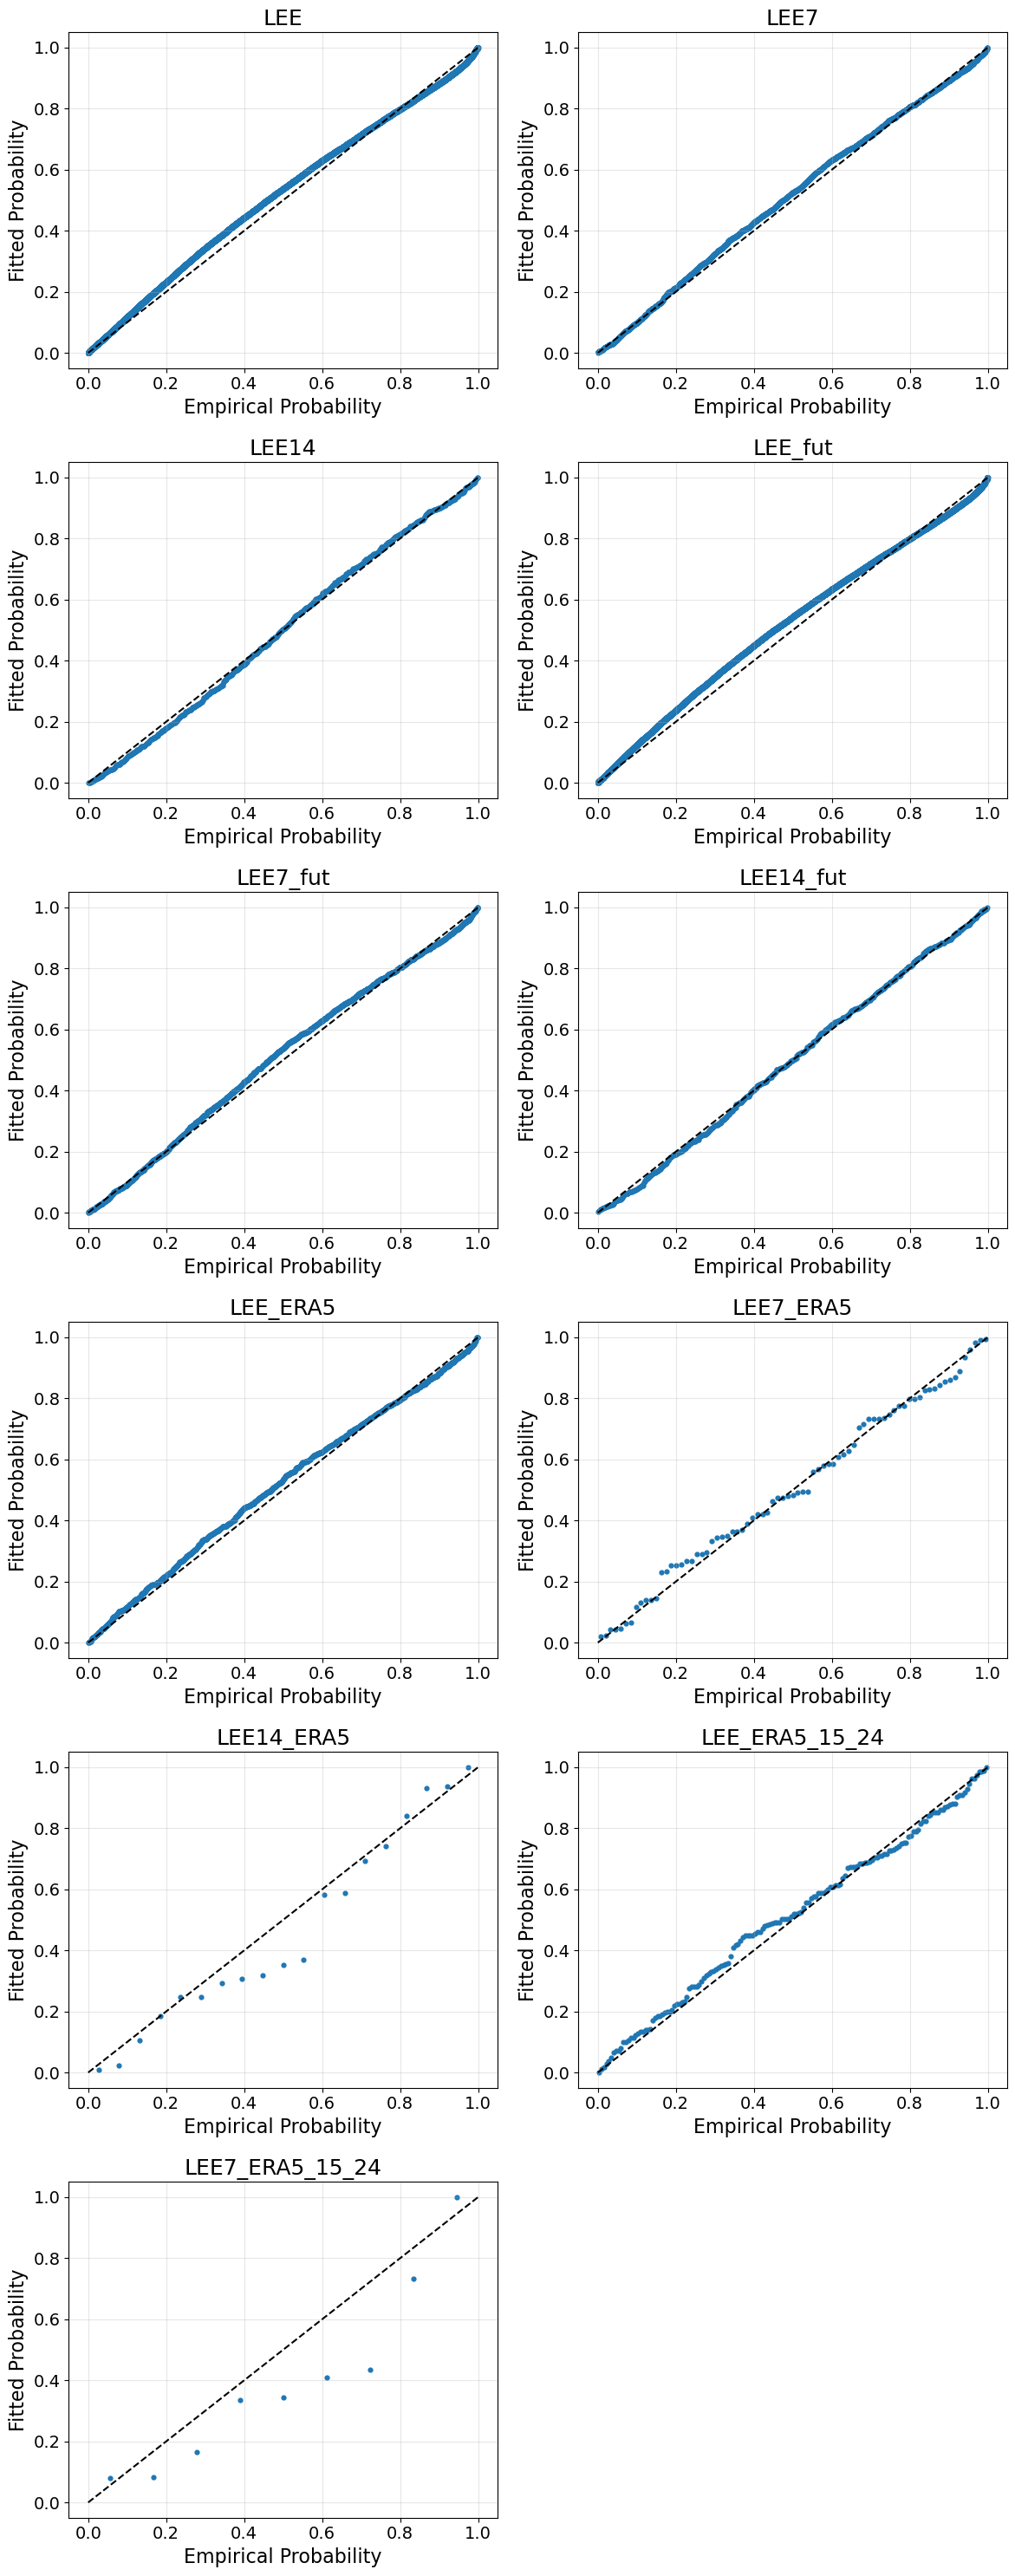

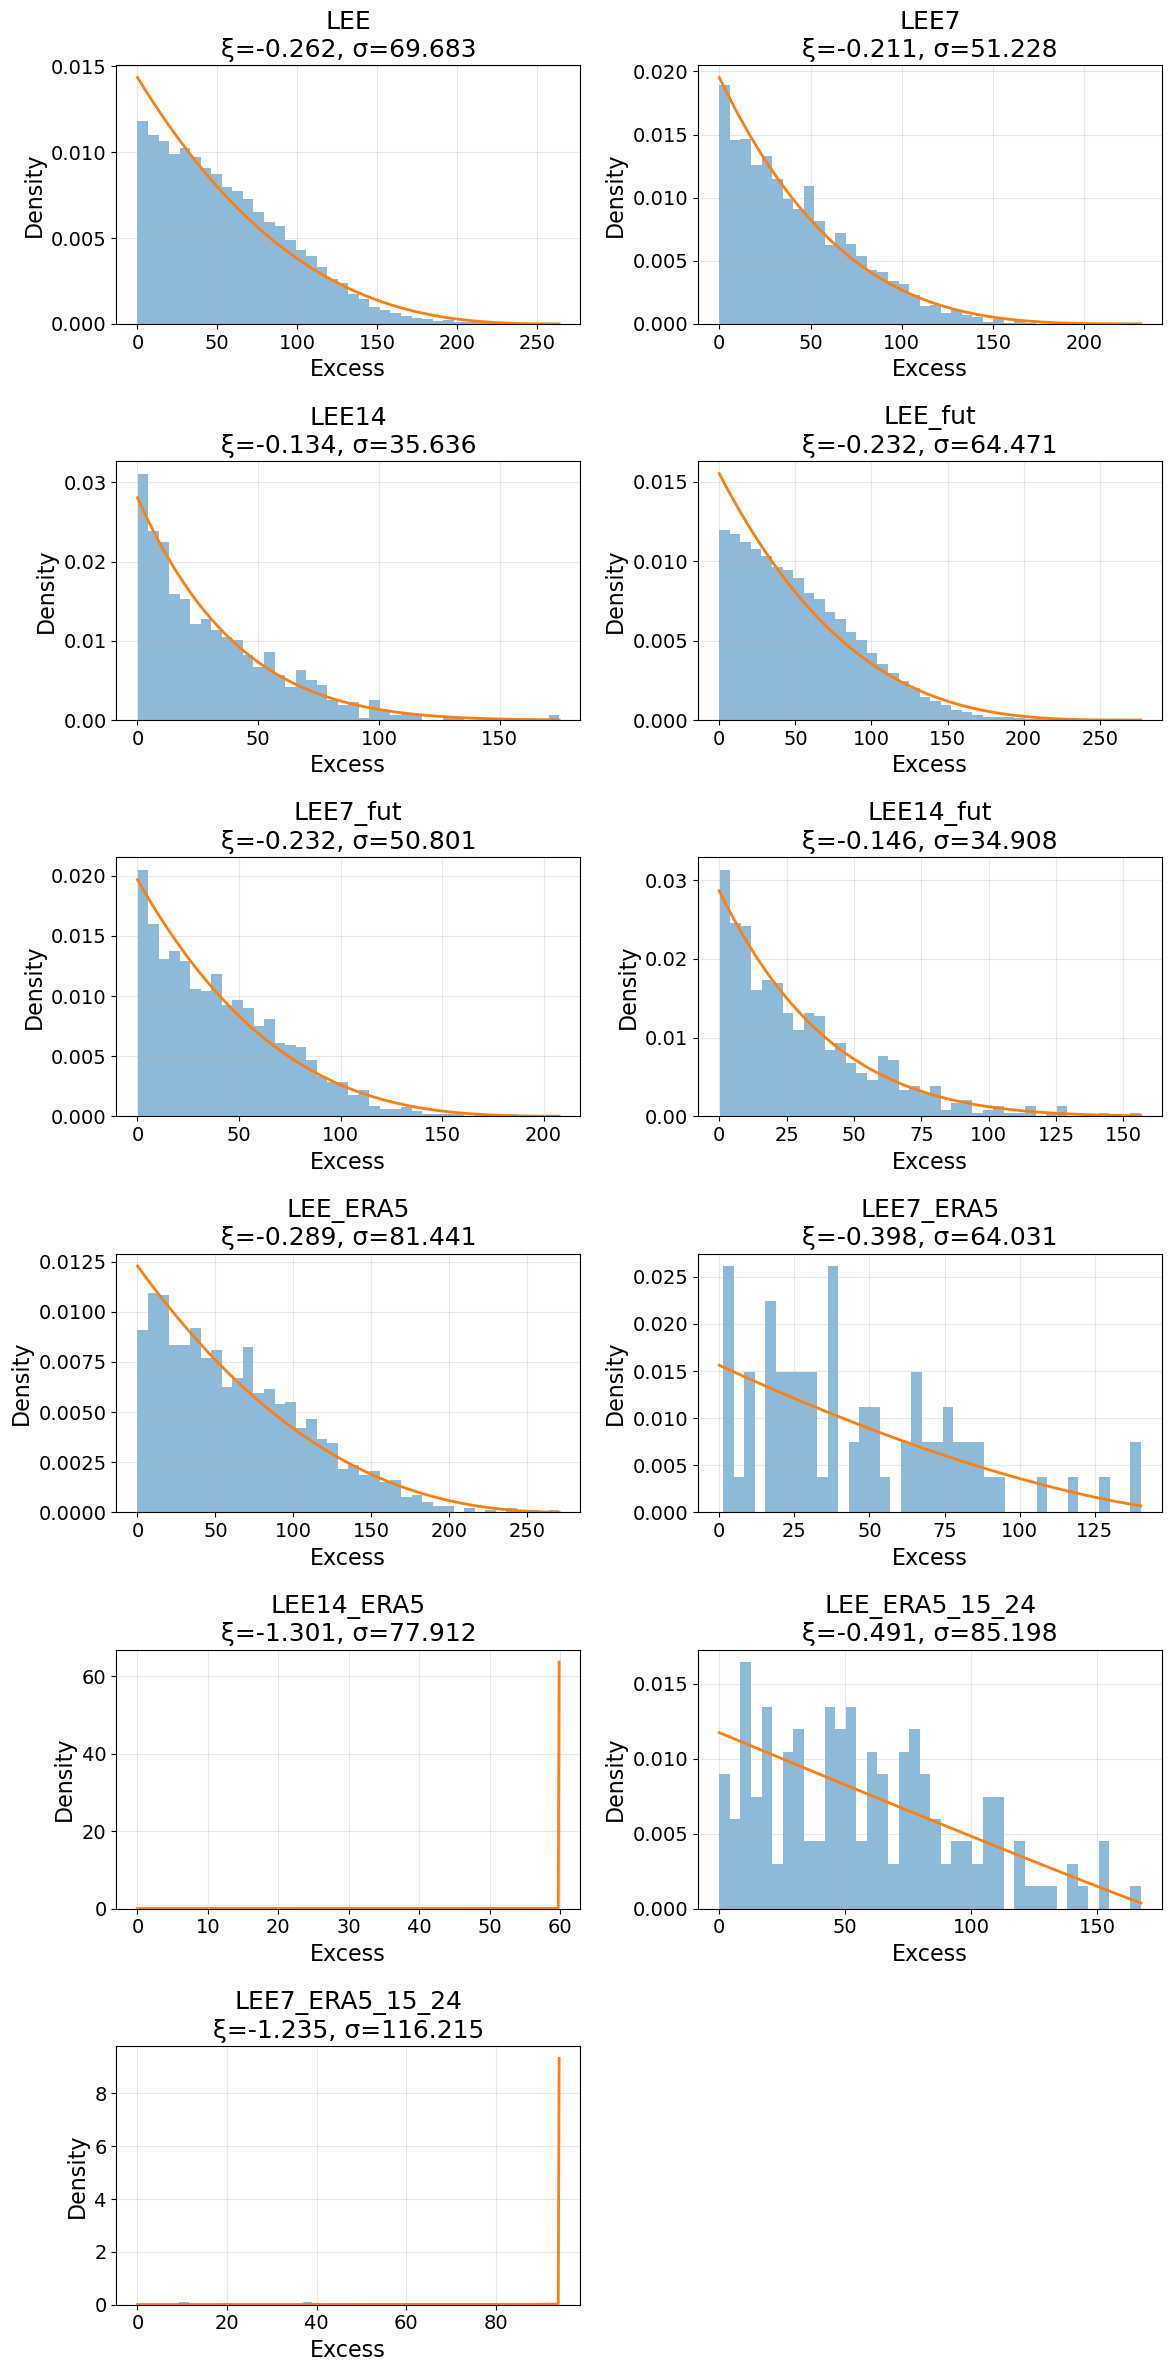

In [19]:
from scipy.stats import genpareto


# ============================================================
# SETTINGS
# ============================================================

T = np.array([1.1, 1.5, 2, 5, 10, 20,
              50, 100, 200, 500,
              1000, 1500, 2000])


# ============================================================
# HELPERS
# ============================================================

def get_nyears(label):

    # IMPORTANT: fixed logical condition
    if ('ERA5' in label) and ('15' in label):
        return 10

    elif 'ERA5' in label:
        return 65

    else:
        return 10 * 192


def fit_gpd(excesses):

    xi, loc, sigma = genpareto.fit(excesses, floc=0)

    return xi, sigma


def return_level(T, u, xi, sigma, lam):

    # Stable xi -> 0 limit
    if abs(xi) < 1e-6:
        return u + sigma * np.log(lam * T)

    return u + (sigma / xi) * ((lam * T)**xi - 1)


# ============================================================
# MAIN FIT STORAGE
# ============================================================

fit_results = {}

for exc, label in zip(excesses, labels):

    xi, sigma = fit_gpd(exc)

    n_years = get_nyears(label)

    lam = len(exc) / n_years

    zT = return_level(T, threshold, xi, sigma, lam)

    fit_results[label] = {
        'excesses': exc,
        'xi': xi,
        'sigma': sigma,
        'lambda': lam,
        'n_years': n_years,
        'zT': zT
    }


# # ============================================================
# # 1. PARAMETER COMPARISON
# # ============================================================

# xis = [fit_results[l]['xi'] for l in labels]
# sigmas = [fit_results[l]['sigma'] for l in labels]
# lambdas = [fit_results[l]['lambda'] for l in labels]

# fig, ax = plt.subplots(3, 1, figsize=(12, 10))

# ax[0].bar(labels, xis)
# ax[0].set_ylabel("Shape ξ")
# ax[0].grid(alpha=0.3)

# ax[1].bar(labels, sigmas)
# ax[1].set_ylabel("Scale σ")
# ax[1].grid(alpha=0.3)

# ax[2].bar(labels, lambdas)
# ax[2].set_ylabel("Exceedance rate λ")
# ax[2].grid(alpha=0.3)

# for a in ax:
#     a.tick_params(axis='x', rotation=90)

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 2. RETURN LEVEL PLOTS
# # ============================================================

# plt.figure(figsize=(10, 6))

# for label in labels:

#     plt.plot(
#         T,
#         fit_results[label]['zT'],
#         marker='o',
#         label=label
#     )

# plt.xscale('log')

# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level')
# plt.title('GPD Return Levels')

# plt.grid(True, which='both',
#          linestyle='--',
#          alpha=0.5)

# plt.legend(bbox_to_anchor=(1.02, 1),
#            loc='upper left')

# plt.tight_layout()
# plt.show()


# # ============================================================
# # 3. RETURN LEVEL PLOTS + EMPIRICAL POINTS
# # ============================================================

# plt.figure(figsize=(12, 7))

# for label in labels:

#     result = fit_results[label]

#     exc = result['excesses']

#     n_years = result['n_years']

#     zT = result['zT']

#     # fitted curve
#     plt.plot(T, zT,
#              linewidth=2,
#              label=label)

#     # empirical return periods
#     exc_sorted = np.sort(exc)[::-1]

#     ranks = np.arange(1, len(exc_sorted)+1)

#     T_emp = n_years / ranks

#     z_emp = threshold + exc_sorted

#     plt.scatter(
#         T_emp,
#         z_emp,
#         s=12,
#         alpha=0.5
#     )

# plt.xscale('log')

# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level')

# plt.title('Return Levels with Empirical Observations')

# plt.grid(True, which='both',
#          linestyle='--',
#          alpha=0.5)

# plt.legend(bbox_to_anchor=(1.02, 1),
#            loc='upper left')

# plt.tight_layout()
# plt.show()


# ============================================================
# 4. QQ PLOTS
# ============================================================

ncols = 2
nrows = int(np.ceil(len(labels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 5 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = np.sort(result['excesses'])

    xi = result['xi']
    sigma = result['sigma']

    n = len(exc)

    p = (np.arange(1, n + 1) - 0.5) / n

    q_theory = genpareto.ppf(
        p,
        c=xi,
        scale=sigma
    )

    ax.scatter(q_theory, exc, s=12)

    maxv = max(q_theory.max(), exc.max())

    ax.plot(
        [0, maxv],
        [0, maxv],
        'k--'
    )

    ax.set_title(label)

    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Empirical Quantiles')

    ax.grid(alpha=0.3)

# remove empty panels
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# ============================================================
# 5. PP PLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 5 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = np.sort(result['excesses'])

    xi = result['xi']
    sigma = result['sigma']

    n = len(exc)

    p_emp = (np.arange(1, n + 1) - 0.5) / n

    p_fit = genpareto.cdf(
        exc,
        c=xi,
        scale=sigma
    )

    ax.scatter(p_emp, p_fit, s=12)

    ax.plot([0, 1],
            [0, 1],
            'k--')

    ax.set_title(label)

    ax.set_xlabel('Empirical Probability')
    ax.set_ylabel('Fitted Probability')

    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# ============================================================
# 6. DENSITY OVERLAY
# ============================================================

ncols = 2
nrows = int(np.ceil(len(labels) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(12, 4 * nrows)
)

axes = axes.flatten()

for i, label in enumerate(labels):

    ax = axes[i]

    result = fit_results[label]

    exc = result['excesses']

    xi = result['xi']
    sigma = result['sigma']

    xgrid = np.linspace(0, exc.max(), 500)

    pdf = genpareto.pdf(
        xgrid,
        c=xi,
        scale=sigma
    )

    ax.hist(
        exc,
        bins=40,
        density=True,
        alpha=0.5
    )

    ax.plot(
        xgrid,
        pdf,
        linewidth=2
    )

    ax.set_title(
        f'{label}\n'
        f'ξ={xi:.3f}, σ={sigma:.3f}'
    )

    ax.set_xlabel('Excess')
    ax.set_ylabel('Density')

    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Fitting GPD for LEE...
Fitting GPD for LEE_fut...


Fitting GPD for LEE_ERA5...
Fitting GPD for LEE_ERA5 (2015-2024)...


/tmp/ipykernel_1168626/1144998967.py:58: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


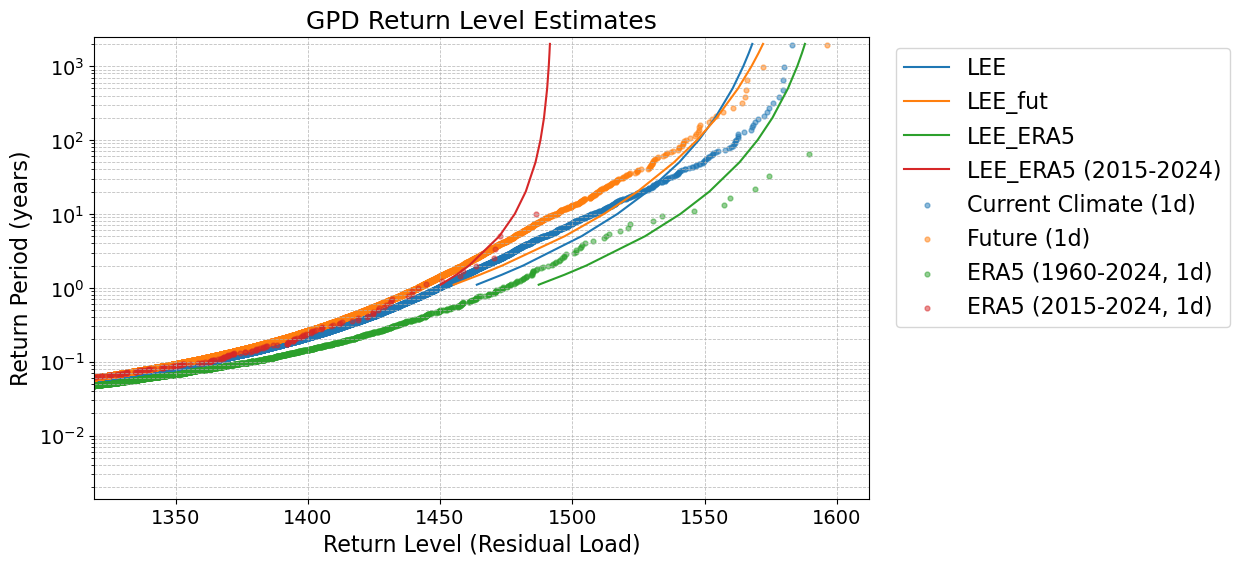

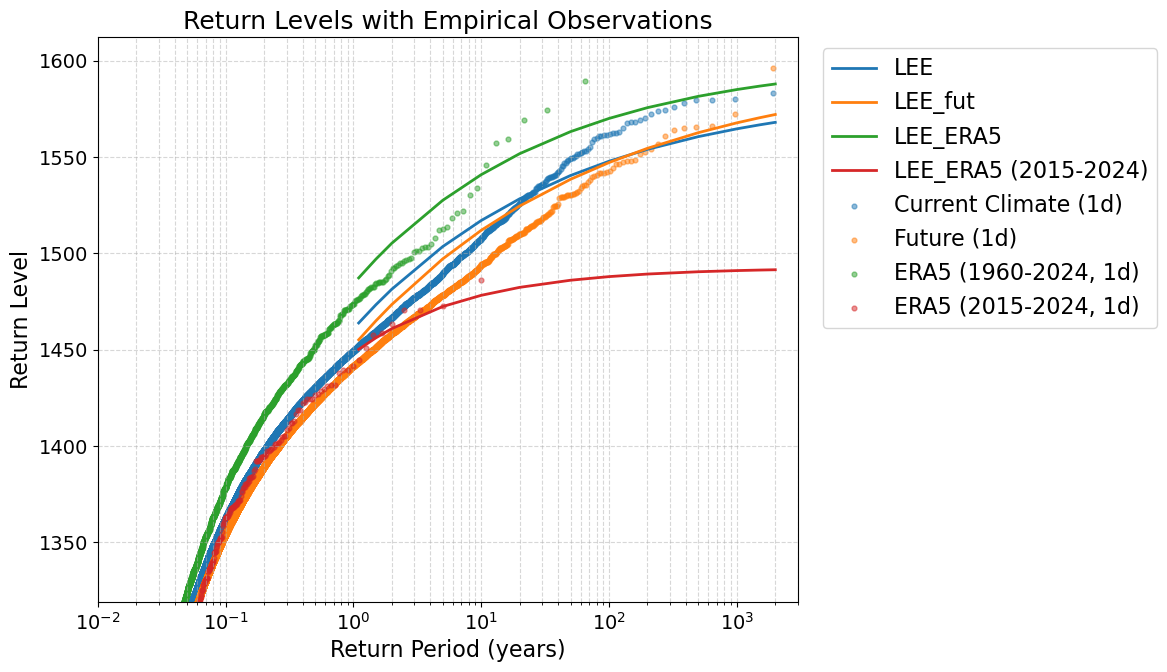

In [20]:
# GPD Fit with return level plots and empirical points
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]

labels = ['Current Climate (1d)', 
          'Future (1d)', 
          'ERA5 (1960-2024, 1d)', 
          'ERA5 (2015-2024, 1d)' ]

T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

excesses = [excesses_LEE, 
            excesses_LEE_fut, 
            excesses_LEE_era,
            excesses_LEE_era5_15_24
            ]
labels_GPD = ['LEE', 
          'LEE_fut',
          'LEE_ERA5',
          'LEE_ERA5 (2015-2024)'
          ]

z_T_list = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list.append(z_T)
    

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels_GPD):
    # marker = '^'
    plt.plot(z_T, T, label=label)
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T_all_point = ((N + 1) / m) / 365


    plt.scatter(x, T_all_point, alpha=0.5, s=12, label=label) # Marker = cross, size = 1


plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()



plt.figure(figsize=(12, 7))

for z_T, label in zip(z_T_list, labels_GPD):
    # marker = '^'
    plt.plot(T, z_T, linewidth=2, label=label)
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x

    # # Return period
    # # T = (N + 1) / (N + 1 - m)
    # T_all_point = ((N + 1) / m) / 365

    plt.scatter(T_emp, z_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.ylim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.xlim(10**-2, 10**3 + 2000)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level')
plt.title('Return Levels with Empirical Observations')

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


# GEV

In [21]:
datasets = [res_load_fut, res_load_fut_7d, res_load_fut_14d,
            res_load_era5_15_24, res_load_era5_15_24_7d, res_load_era5_15_24_14d,
            res_load_curr_clim, res_load_curr_clim_7d , res_load_curr_clim_14d,
            res_load_ERA5, res_load_ERA5_7d , res_load_ERA5_14d]
res_load_fut_sm = res_load_fut.groupby('winter_season').max(dim='time').values.ravel()
res_load_fut_7d_sm = res_load_fut_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_fut_14d_sm = res_load_fut_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_era5_15_24_sm = res_load_era5_15_24.groupby('winter_season').max(dim='time').values.ravel()
res_load_era5_15_24_7d_sm = res_load_era5_15_24_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_era5_15_24_14d_sm = res_load_era5_15_24_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_curr_clim_sm = res_load_curr_clim.groupby('winter_season').max(dim='time').values.ravel()
res_load_curr_clim_7d_sm = res_load_curr_clim_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_curr_clim_14d_sm = res_load_curr_clim_14d.groupby('winter_season').max(dim='time').values.ravel()

res_load_ERA5_sm = res_load_ERA5.groupby('winter_season').max(dim='time').values.ravel()
res_load_ERA5_7d_sm = res_load_ERA5_7d.groupby('winter_season').max(dim='time').values.ravel()
res_load_ERA5_14d_sm = res_load_ERA5_14d.groupby('winter_season').max(dim='time').values.ravel()

In [22]:
seasonal_maxima = [res_load_fut_sm, res_load_fut_7d_sm, res_load_fut_14d_sm,
            res_load_era5_15_24_sm, res_load_era5_15_24_7d_sm, res_load_era5_15_24_14d_sm,
            res_load_curr_clim_sm, res_load_curr_clim_7d_sm , res_load_curr_clim_14d_sm,
            res_load_ERA5_sm, res_load_ERA5_7d_sm , res_load_ERA5_14d_sm]

labels = ['Future (1d)', 'Future (7d)', 'Future (14d)',
          'ERA5 (2015-2024, 1d)', 'ERA5 (2015-2024, 7d)', 'ERA5 (2015-2024, 14d)',
          'Current Climate (1d)', 'Current Climate (7d)', 'Current Climate (14d)',
          'ERA5 (1960-2024, 1d)', 'ERA5 (1960-2024, 7d)', 'ERA5 (1960-2024, 14d)']

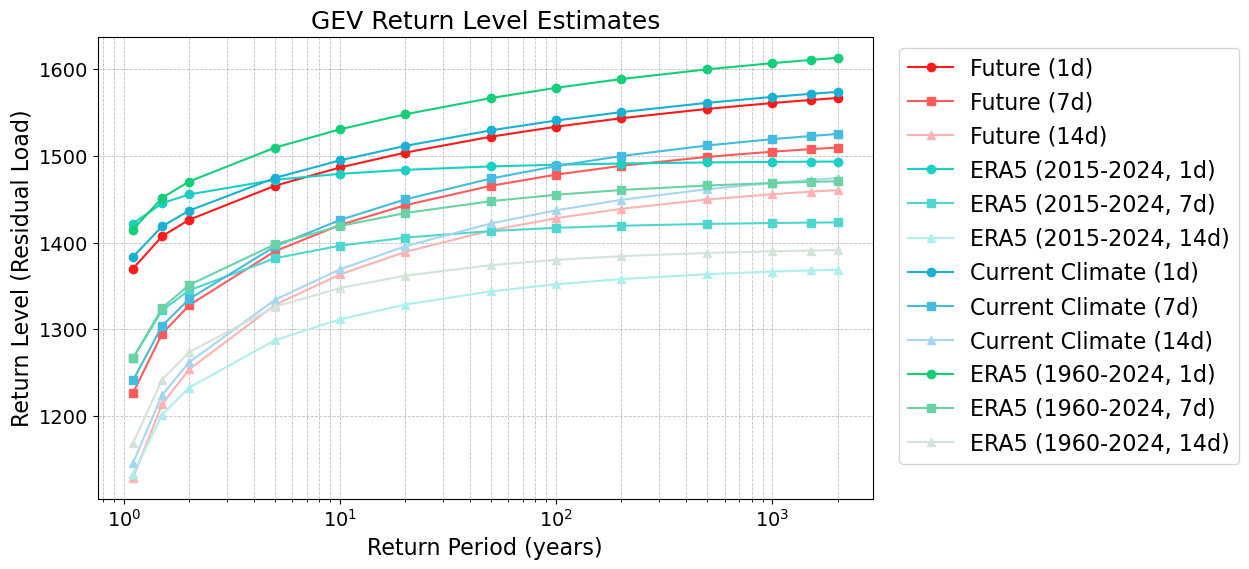

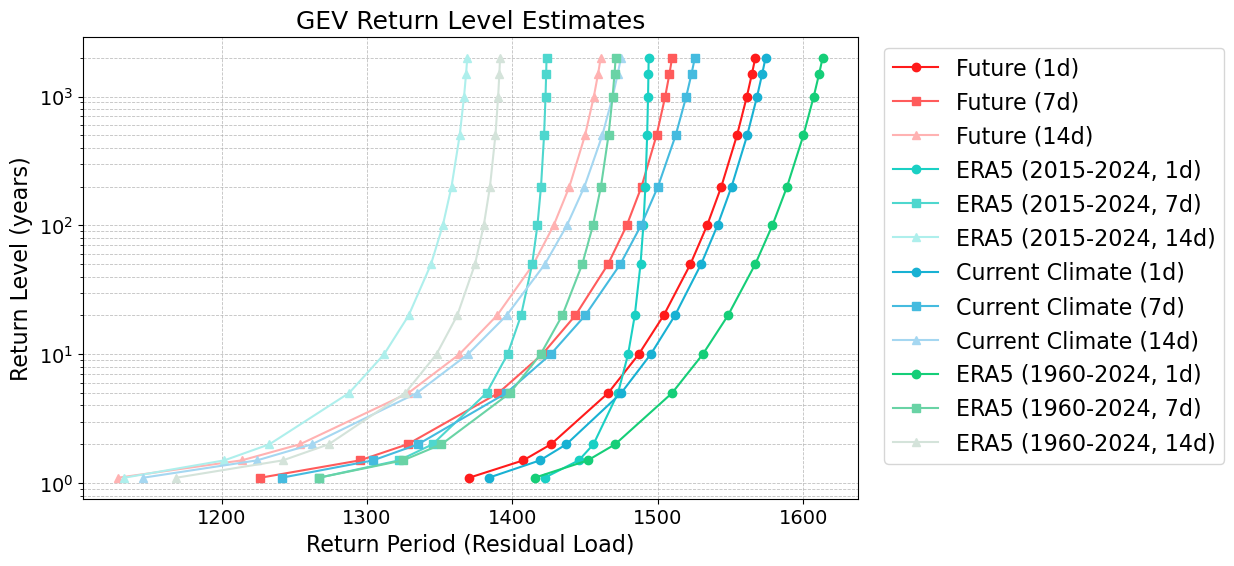

In [23]:
seasonal_maxima = [res_load_fut_sm, res_load_fut_7d_sm, res_load_fut_14d_sm,
            res_load_era5_15_24_sm, res_load_era5_15_24_7d_sm, res_load_era5_15_24_14d_sm,
            res_load_curr_clim_sm, res_load_curr_clim_7d_sm , res_load_curr_clim_14d_sm,
            res_load_ERA5_sm, res_load_ERA5_7d_sm , res_load_ERA5_14d_sm]

labels = ['Future (1d)', 'Future (7d)', 'Future (14d)',
          'ERA5 (2015-2024, 1d)', 'ERA5 (2015-2024, 7d)', 'ERA5 (2015-2024, 14d)',
          'Current Climate (1d)', 'Current Climate (7d)', 'Current Climate (14d)',
          'ERA5 (1960-2024, 1d)', 'ERA5 (1960-2024, 7d)', 'ERA5 (1960-2024, 14d)']

# Make a color scale with a different color for each time frame and a different shade for each data source (CMIP vs ERA5)
colors = [
    # Future
    "#FF1B1B",  # Future (1d) - dark red
    "#FF5B5B",  # Future (7d) - soft red
    '#FFB2B2',  # Future (14d) - Lightest red

    # ERA5 (2015-2024)
    "#1AD0C4",  # ERA5 (2015-2024, 1d) - Teal
    "#4ED7CE",  # ERA5 (2015-2024, 7d) - Lighter teal
    '#AEEFEC',  # ERA5 (2015-2024, 14d) - Lightest teal

    # Current Climate
    "#18B1D3",  # Current Climate (1d) - Sky blue
    "#45BBDF",  # Current Climate (7d) - Lighter sky blue
    '#A5D7F1',  # Current Climate (14d) - Lightest sky blue

    # ERA5 (1960-2024)
    "#15CE78",  # ERA5 (1960-2024, 1d) - Mint green
    "#69D3A5",  # ERA5 (1960-2024, 7d) - Lighter mint green
    '#D4E3DA'   # ERA5 (1960-2024, 14d) - Lightest mint green
]


z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    # print(f"Fitting GEV for {label}...")
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    if '1d' in label:
        marker = 'o'
    elif '7d' in label:
        marker = 's'
    else:        
        marker = '^'
    plt.plot(T, z_T, marker=marker, label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    if '1d' in label:
        marker = 'o'
    elif '7d' in label:
        marker = 's'
    else:        
        marker = '^'
    plt.plot(z_T,T, marker=marker, label=label, color=color)
plt.yscale('log')
plt.xlabel('Return Period (Residual Load)')
plt.ylabel('Return Level (years)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (1d)...
Fitting GEV for ERA5 (2015-2024, 1d)...
Fitting GEV for Current Climate (1d)...
Fitting GEV for ERA5 (1960-2024, 1d)...


/tmp/ipykernel_1168626/3204027361.py:158: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


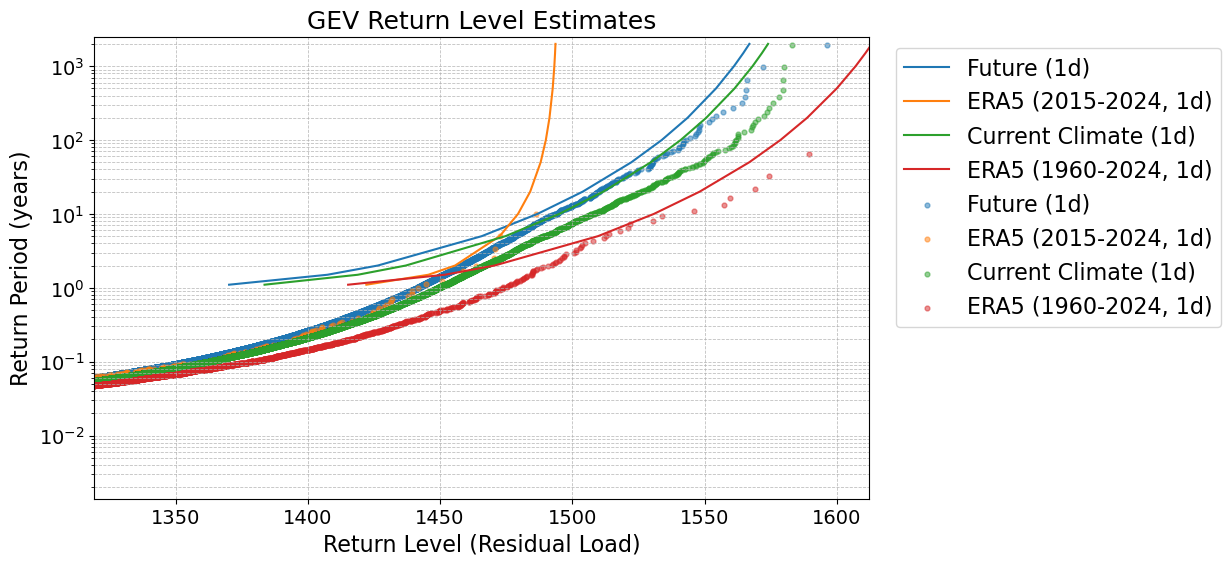

In [24]:
seasonal_maxima = [res_load_fut_sm, 
            res_load_era5_15_24_sm, 
            res_load_curr_clim_sm, 
            res_load_ERA5_sm]

RLs = [res_load_fut_1d, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_ERA5]

labels = ['Future (1d)', 
          'ERA5 (2015-2024, 1d)', 
          'Current Climate (1d)', 
          'ERA5 (1960-2024, 1d)' ]

z_T_list = []
z_T_list_2 = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)
    
    # x_fit_std = np.linspace(x_std.min()-1, x_std.max()+1, 500)

    # p_fit = genextreme.sf(
    #     x_fit_std,
    #     shape,
    #     loc=loc,
    #     scale=scale
    # )

    # # back transform
    # x_fit = x_fit_std * sigma + mu

    # z_T_list_2.append((x_fit, p_fit))


# # Plot return levels
# plt.figure(figsize=(10, 6))
# # for z_T, label in zip(z_T_list_2, labels):
#     # marker = '^'
# for (x_fit, p_fit), label in zip(z_T_list_2, labels):
#     plt.plot(x_fit, p_fit, label=label)
#     # plt.plot(z_T, T, label=label)
# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort ascending
#     x = np.sort(extremes)

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     T_all_point = (1 - (m/(N+1)))
        
#     plt.scatter(x, T_all_point, marker='x', s=10, label=label) # Marker = cross, size = 1


# plt.yscale('log')
# plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
# plt.ylim(10**-9, 0)
# plt.xlabel('Return Period (years)')
# plt.ylabel('Return Level (Residual Load)')
# plt.title('GEV Return Level Estimates')
# plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.show()


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    # marker = '^'
    plt.plot(z_T, T, label=label)
# for res_load, label in zip(RLs, labels):

#     # Example: extreme residual load values
#     extremes = res_load # your event values

#     # Sort ascending
#     x = np.sort(extremes)[::-1]

#     # Rank
#     m = np.arange(1, len(x) + 1)

#     # Total observation period (important!)
#     N = len(extremes)  # OR number of years, depending on method

#     # Return period
#     # T = (N + 1) / (N + 1 - m)
#     T_all_point = (N + 1) / m 
        


#     plt.scatter(x, T_all_point/365, marker='x', s=10, label=label) # Marker = cross, size = 1
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x

    # # Return period
    # # T = (N + 1) / (N + 1 - m)
    # T_all_point = ((N + 1) / m) / 365

    plt.scatter(z_emp, T_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (1d)...
Fitting GEV for ERA5 (2015-2024, 1d)...
Fitting GEV for Current Climate (1d)...
Fitting GEV for ERA5 (1960-2024, 1d)...


/tmp/ipykernel_1168626/1501391703.py:78: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


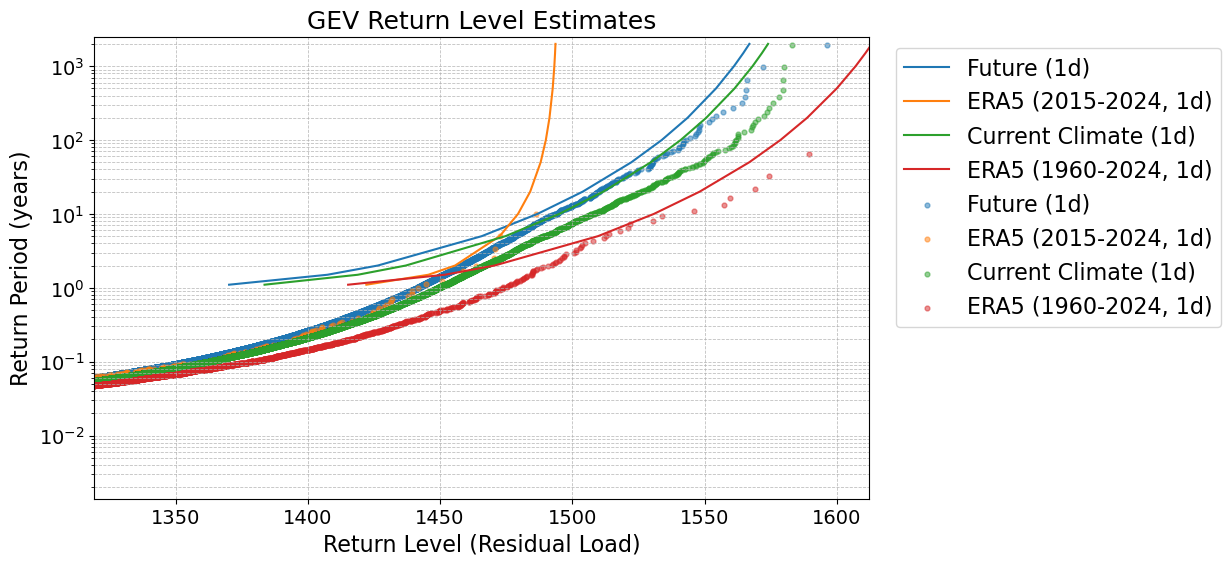

In [25]:
seasonal_maxima = [res_load_fut_sm, 
            res_load_era5_15_24_sm, 
            res_load_curr_clim_sm, 
            res_load_ERA5_sm]

RLs = [res_load_fut_1d, res_load_era5_15_24_1d, res_load_curr_clim_1d, res_load_ERA5]

labels = ['Future (1d)', 
          'ERA5 (2015-2024, 1d)', 
          'Current Climate (1d)', 
          'ERA5 (1960-2024, 1d)' ]

z_T_list = []
z_T_list_2 = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    # marker = '^'
    plt.plot(z_T, T, label=label)

#     plt.scatter(x, T_all_point/365, marker='x', s=10, label=label) # Marker = cross, size = 1
for res_load, label in zip(RLs, labels):

    # Example: extreme residual load values
    extremes = res_load - threshold # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    if 'ERA5' in label and '15' in label:
        N = 10  # ERA5 2015-2024
    elif 'ERA5' in label:
        N = 65  # ERA5 1960-2024
    else:
        N = 10 * 192  # CMIP6 runs
    
    T_emp = N / m
    
    z_emp = threshold + x


    plt.scatter(z_emp, T_emp, alpha=0.5, s=12, label=label) # Marker = cross, size = 1

plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.01)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

/tmp/ipykernel_1168626/1331483698.py:101: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 2500)


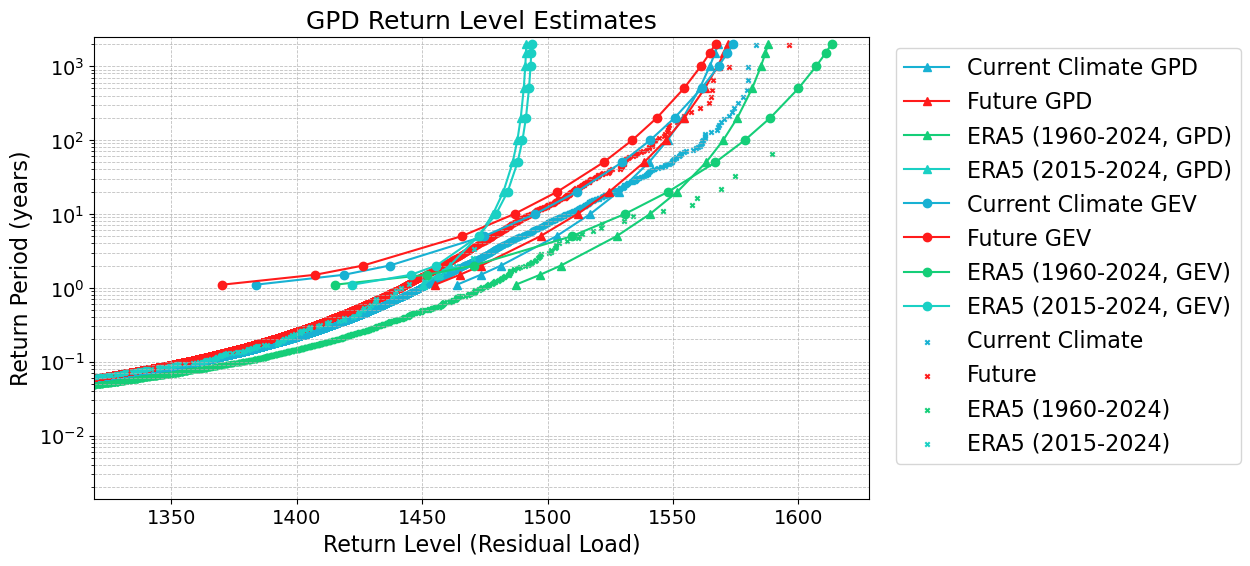

In [26]:
# 1 Day event GEV/GPD return levels comparison
RLs = [res_load_curr_clim_1d, res_load_fut_1d, res_load_ERA5, res_load_era5_15_24_1d]

seasonal_maxima = [res_load_curr_clim_sm, res_load_fut_sm, res_load_ERA5_sm, res_load_era5_15_24_sm]

labels = ['Current Climate', 
          'Future', 
          'ERA5 (1960-2024)', 
          'ERA5 (2015-2024)' ]

labels_GEV = ['Current Climate GEV', 
          'Future GEV', 
          'ERA5 (1960-2024, GEV)', 
          'ERA5 (2015-2024, GEV)' ]

colors = [
    "#18B1D3",  # Current Climate (1d) - Sky blue
    "#FF1B1B",  # Future (1d) - dark red
    "#15CE78",  # ERA5 (1960-2024, 1d) - Mint green
    "#1AD0C4",  # ERA5 (2015-2024, 1d) - Teal
]

T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

excesses = [excesses_LEE, 
            excesses_LEE_fut, 
            excesses_LEE_era,
            excesses_LEE_era5_15_24
            ]


labels_GPD = ['Current Climate GPD', 
          'Future GPD', 
          'ERA5 (1960-2024, GPD)', 
          'ERA5 (2015-2024, GPD)' ]

z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    # print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


z_T_list_GEV = []
for seas_max in seasonal_maxima:

    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list_GEV.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors):
    marker = '^'
    plt.plot(z_T, T, label=label, color=color, marker=marker)
for z_T, label, color in zip(z_T_list_GEV, labels_GEV, colors):
    marker = 'o'
    plt.plot(z_T, T, label=label, color=color, marker=marker)
for res_load, label, color in zip(RLs, labels, colors):

    # Example: extreme residual load values
    extremes = res_load # your event values

    # Sort descending
    x = np.sort(extremes)[::-1]

    # Rank
    m = np.arange(1, len(x) + 1)

    # Total observation period (important!)
    N = len(extremes)  # OR number of years, depending on method

    # Return period
    # T = (N + 1) / (N + 1 - m)
    T_all_point = ((N + 1) / m) / 365

    plt.scatter(x, T_all_point, marker='x', s=10, label=label, color=color) # Marker = cross, size = 1


plt.yscale('log')
plt.xlim(np.float64(1319.138650687668), np.float64(1596.223514139268)*1.02)
plt.ylim(0, 2500)
plt.ylabel('Return Period (years)')
plt.xlabel('Return Level (Residual Load)')
plt.title('GPD Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (7d)...
Fitting GEV for ERA5 (2015-2024, 7d)...
Fitting GEV for Current Climate (7d)...
Fitting GEV for ERA5 (1960-2024, 7d)...


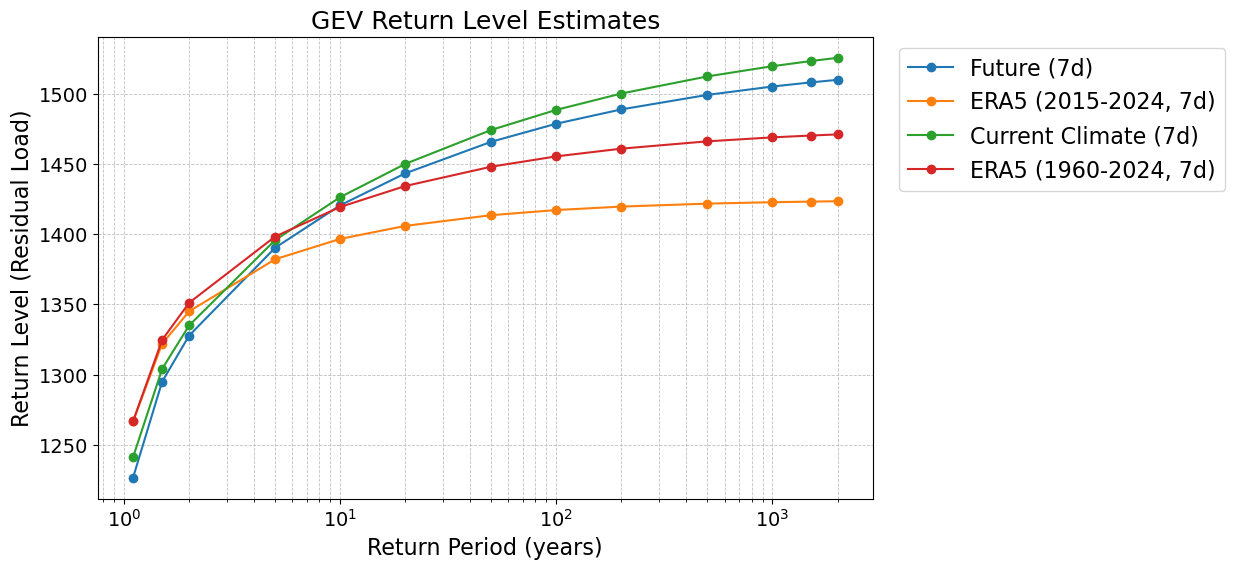

In [27]:
seasonal_maxima = [res_load_fut_7d_sm,
            res_load_era5_15_24_7d_sm, 
            res_load_curr_clim_7d_sm , 
            res_load_ERA5_7d_sm]

labels = ['Future (7d)',
          'ERA5 (2015-2024, 7d)', 
          'Current Climate (7d)', 
          'ERA5 (1960-2024, 7d)']

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GPD for GPD Current Climate...
Fitting GPD for GPD Future...
Fitting GPD for GPD ERA5 (1960-2024)...


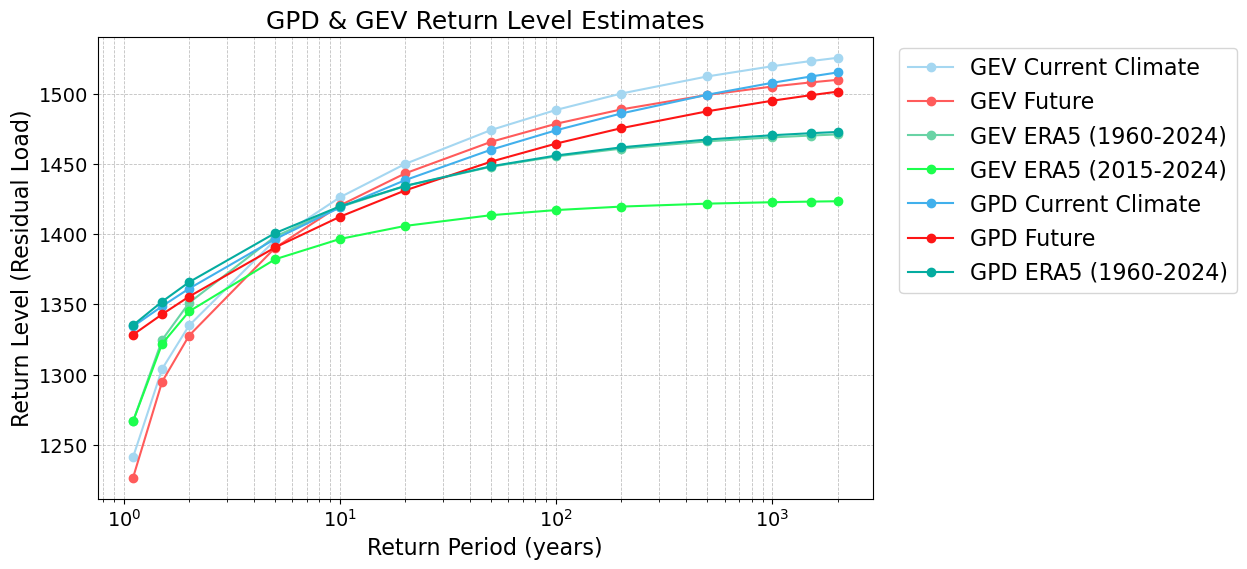

In [28]:
# 7 Day event GEV/GPD return levels comparison
seasonal_maxima = [res_load_curr_clim_7d_sm, 
                   res_load_fut_7d_sm,
                   res_load_ERA5_7d_sm,
                   res_load_era5_15_24_7d_sm]

labels = ['GEV Current Climate', 
          'GEV Future',
          'GEV ERA5 (1960-2024)', 
          'GEV ERA5 (2015-2024)']

colors = [
    '#A5D7F1',  # Current Climate (7d) - Lightest sky blue
    "#FF5B5B",  # Future (7d) - soft red
    "#69D3A5",  # ERA5 (1960-2024, 7d) - Lighter mint green
    "#1CFF4D",  # ERA5 (2015-2024, 7d) - Lighter teal
]

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

excesses = [excesses_LEE7, excesses_LEE7_fut, excesses_LEE7_era]
labels_GPD = [
          'GPD Current Climate',
          'GPD Future',
          'GPD ERA5 (1960-2024)']
colors_GPD = [
    "#41B0EC",  # Current Climate (7d) - Lightest sky blue
    "#FD1515",  # Future (7d) - soft red
    "#04ACA0",  # ERA5 (2015-2024, 7d) - Lighter teal
]


z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    plt.plot(T, z_T, marker='o', label=label, color=color)
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors_GPD):
    plt.plot(T, z_T, marker='o', label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD & GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GEV for Future (14d)...
Fitting GEV for ERA5 (2015-2024, 14d)...
Fitting GEV for Current Climate (14d)...
Fitting GEV for ERA5 (1960-2024, 14d)...


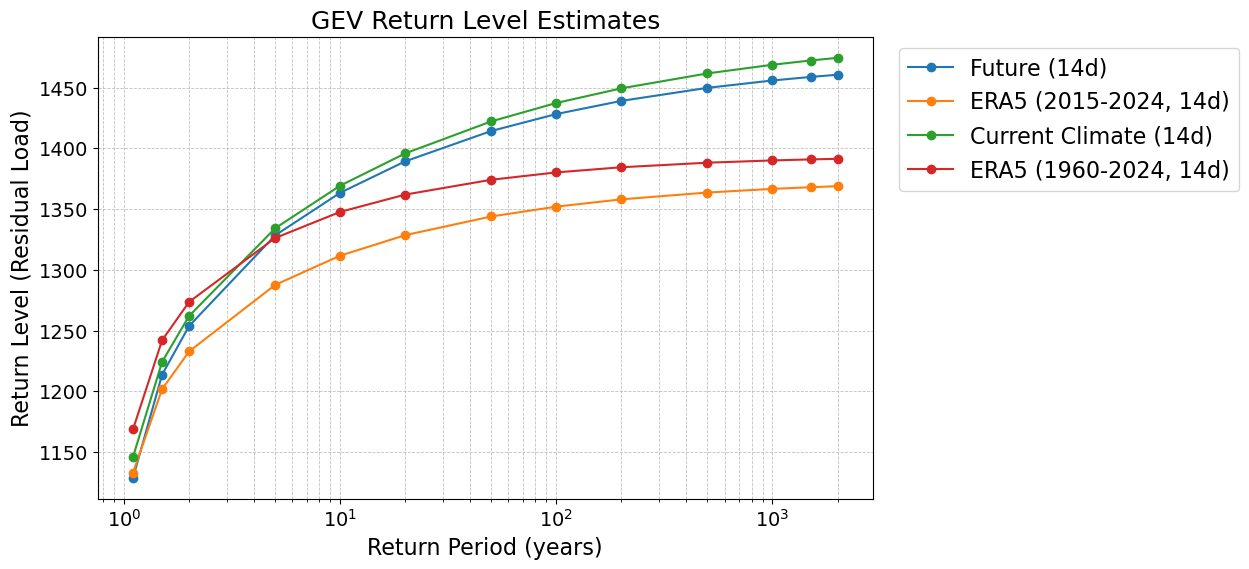

In [29]:
seasonal_maxima = [res_load_fut_14d_sm,
            res_load_era5_15_24_14d_sm,
            res_load_curr_clim_14d_sm,
            res_load_ERA5_14d_sm]

labels = ['Future (14d)',
          'ERA5 (2015-2024, 14d)',
          'Current Climate (14d)',
          'ERA5 (1960-2024, 14d)']

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    print(f"Fitting GEV for {label}...")
    
    
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label in zip(z_T_list, labels):
    plt.plot(T, z_T, marker='o', label=label)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

Fitting GPD for GPD Current Climate...
Fitting GPD for GPD Future...
Fitting GPD for GPD ERA5 (1960-2024)...


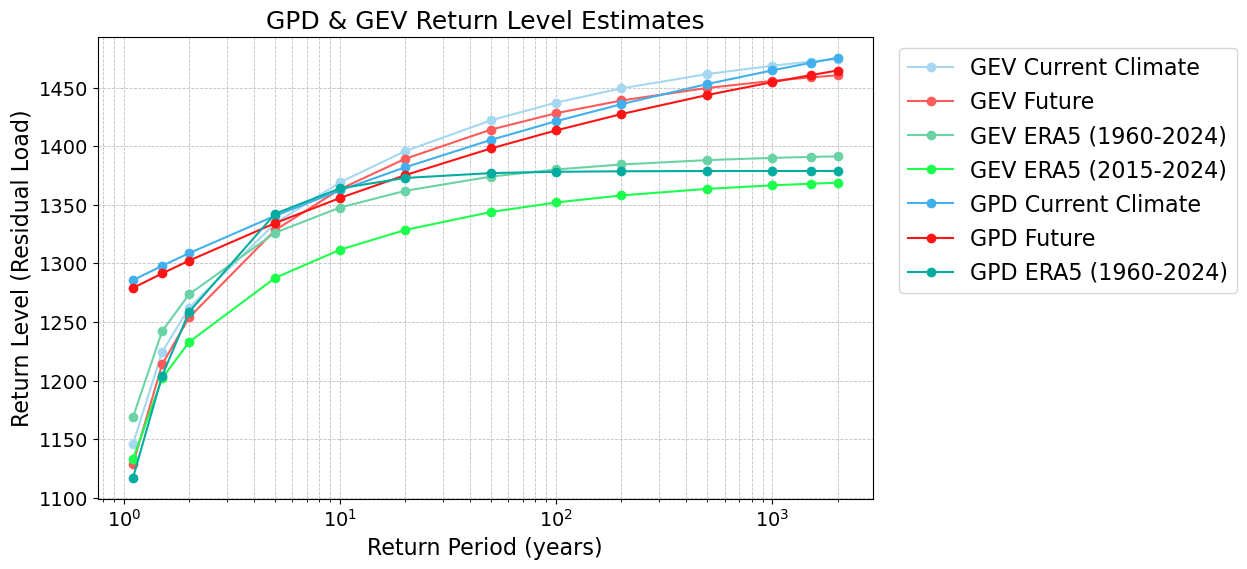

In [30]:
# 14 Day event GEV/GPD return levels comparison
seasonal_maxima = [res_load_curr_clim_14d_sm, 
                   res_load_fut_14d_sm,
                   res_load_ERA5_14d_sm,
                   res_load_era5_15_24_14d_sm]

labels = ['GEV Current Climate', 
          'GEV Future',
          'GEV ERA5 (1960-2024)', 
          'GEV ERA5 (2015-2024)']

colors = [
    '#A5D7F1',  # Current Climate (14d) - Lightest sky blue
    "#FF5B5B",  # Future (14d) - soft red
    "#69D3A5",  # ERA5 (1960-2024, 14d) - Lighter mint green
    "#1CFF4D",  # ERA5 (2015-2024, 14d) - Lighter teal
]

z_T_list = []
T = np.array([1.1, 1.5, 2, 5, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years

for seas_max, label in zip(seasonal_maxima, labels):
    x = np.asarray(seas_max)

    # standardize
    x_std = (x - x.mean()) / x.std()

    shape, loc, scale = genextreme.fit(x_std)
    
    # shape, loc, scale = genextreme.fit(seas_max)

    # return levels
    # z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
    
    mu = x.mean()
    sigma = x.std()

    z_T_std = genextreme.ppf(
        1 - 1/T,
        shape,
        loc=loc,
        scale=scale
    )

    # transform back
    z_T = z_T_std * sigma + mu
    
    z_T_list.append(z_T)

excesses = [excesses_LEE14, excesses_LEE14_fut, excesses_LEE14_era]
labels_GPD = [
          'GPD Current Climate',
          'GPD Future',
          'GPD ERA5 (1960-2024)']
colors_GPD = [
    "#41B0EC",  # Current Climate (7d) - Lightest sky blue
    "#FD1515",  # Future (7d) - soft red
    "#04ACA0",  # ERA5 (2015-2024, 7d) - Lighter teal
]


z_T_list_GPD = []
for exc, label in zip(excesses, labels_GPD):
    print(f"Fitting GPD for {label}...")
    z_T = GPD_fit(exc, threshold, label)
    z_T_list_GPD.append(z_T)


# Plot return levels
plt.figure(figsize=(10, 6))
for z_T, label, color in zip(z_T_list, labels, colors):
    plt.plot(T, z_T, marker='o', label=label, color=color)
for z_T, label, color in zip(z_T_list_GPD, labels_GPD, colors_GPD):
    plt.plot(T, z_T, marker='o', label=label, color=color)
plt.xscale('log')
plt.xlabel('Return Period (years)')
plt.ylabel('Return Level (Residual Load)')
plt.title('GPD & GEV Return Level Estimates')
plt.grid(True, which='both', linestyle='--', linewidth=0.6, alpha=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

In [31]:
x = np.asarray(res_load_fut_sm)

# standardize
x_std = (x - x.mean()) / x.std()

shape, loc, scale = genextreme.fit(x_std)

print(shape, loc, scale)

0.22472208151606737 -0.3835055852044337 1.031601328373896


In [32]:

shape, loc, scale = genextreme.fit(res_load_curr_clim_7d_sm)

# return levels
T = np.array([1.1, 10, 20, 50, 100, 200, 500, 1000, 1500, 2000])  # in years
z_T = genextreme.ppf(1 - 1/T, shape, loc=loc, scale=scale)
z_T

array([1222.38793759, 1550.06153006, 1550.06153174, 1550.06153176,
       1550.06153176, 1550.06153176, 1550.06153176, 1550.06153176,
       1550.06153176, 1550.06153176])

In [33]:
shape, loc, scale = genextreme.fit(res_load_fut_sm)

print(shape, loc, scale)

7.330195208476984 1595.728653272607 3.627426753660716


Standardized fit:
shape = 0.21695058410932722
loc   = -0.38013513713226477
scale = 1.0037247076081086

Original-scale parameters:
shape = 0.21695058410932722
loc   = 1422.7529422511152
scale = 40.62753853971841


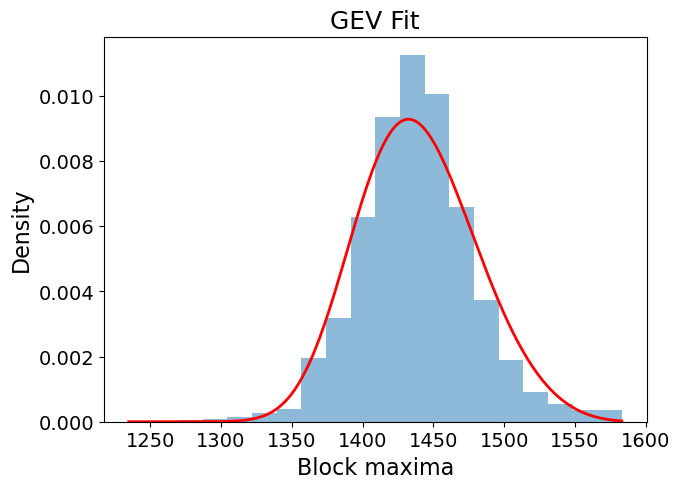

100-year return level: 1540.9902647764773


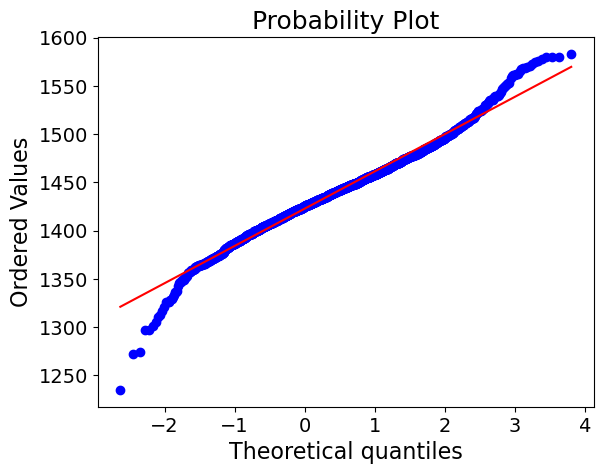

In [34]:

x_data = np.asarray(res_load_curr_clim_sm)

# -----------------------------------
# Standardize
# -----------------------------------

mu = x_data.mean()
sigma = x_data.std()

x_std = (x_data - mu) / sigma

# -----------------------------------
# Fit GEV on standardized data
# -----------------------------------

shape, loc, scale = genextreme.fit(x_std)

print("Standardized fit:")
print("shape =", shape)
print("loc   =", loc)
print("scale =", scale)

# -----------------------------------
# Transform parameters back
# -----------------------------------

loc_orig = mu + sigma * loc
scale_orig = sigma * scale

print("\nOriginal-scale parameters:")
print("shape =", shape)
print("loc   =", loc_orig)
print("scale =", scale_orig)

# -----------------------------------
# PDF plot
# -----------------------------------

x = np.linspace(x_data.min(), x_data.max(), 200)

pdf = genextreme.pdf(
    x,
    shape,
    loc=loc_orig,
    scale=scale_orig
)

plt.figure(figsize=(7,5))

plt.hist(x_data, bins=20, density=True, alpha=0.5)

plt.plot(x, pdf, 'r-', lw=2)

plt.xlabel("Block maxima")
plt.ylabel("Density")
plt.title("GEV Fit")

plt.show()

# -----------------------------------
# Return level
# -----------------------------------

T = 100

return_level = genextreme.ppf(
    1 - 1/T,
    shape,
    loc=loc_orig,
    scale=scale_orig
)

print("100-year return level:", return_level)
from scipy.stats import probplot

probplot(res_load_curr_clim_sm, dist=genextreme, sparams=(shape,), plot=plt)
plt.show()


In [35]:
print("min:", res_load_fut_sm.min())
print("max:", res_load_fut_sm.max())
print("mean:", res_load_fut_sm.mean())
print("std:", res_load_fut_sm.std())

print("shape =", shape)
print("loc =", loc)
print("scale =", scale)

min: 1206.8130529947678
max: 1596.223514139268
mean: 1427.327612203385
std: 41.36830948959141
shape = 0.21695058410932722
loc = -0.38013513713226477
scale = 1.0037247076081086


In [36]:
print(len(res_load_fut_sm))

2112


In [37]:
from scipy.stats import gumbel_r

loc_g, scale_g = gumbel_r.fit(res_load_fut_sm)

print("Gumbel fit - loc:", loc_g)
print("Gumbel fit - scale:", scale_g)

Gumbel fit - loc: 1406.5345120774816
Gumbel fit - scale: 47.18227221151888


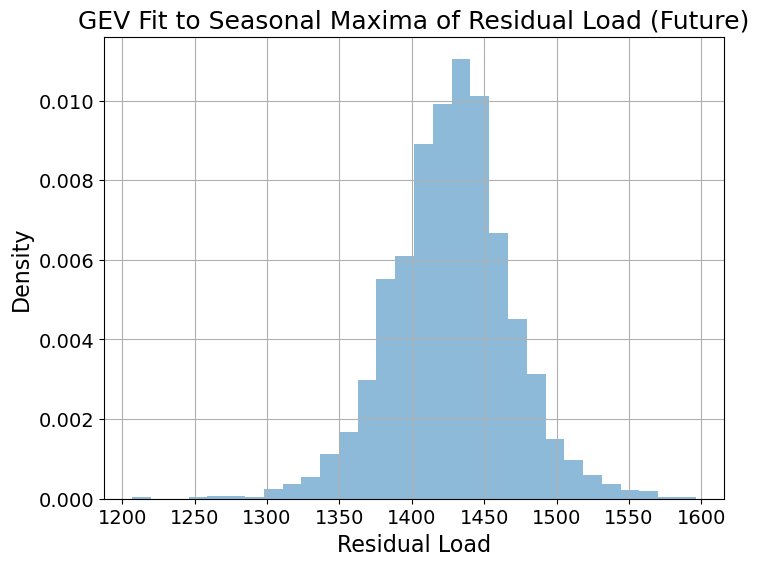

In [38]:
#Plot res_load_fut_sm as a pdf

x = np.linspace(min(res_load_fut_sm), max(res_load_fut_sm), 100)
# pdf = genextreme.pdf(x, shape, loc=loc, scale=scale)
plt.figure(figsize=(8, 6))
# plt.plot(x, pdf, label='GEV PDF Fit')
plt.hist(res_load_fut_sm, bins=30, density=True, alpha=0.5, label='Seasonal Maxima Data')
plt.xlabel('Residual Load')
plt.ylabel('Density')
plt.title('GEV Fit to Seasonal Maxima of Residual Load (Future)')
# plt.legend()
plt.grid()
plt.show()

In [39]:
idx = LEE_dat_ERA5_15_24.groupby('winter_season')['RL_mean'].idxmax()
result = LEE_dat_ERA5_15_24.loc[idx]
result

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
29176,2015-01-20,2015-01-20,2015-01-20,19,19,19,1,1439.293940,1439.293940,0.0,1439.293940,29177,ERA5_week,ERA5_hist_week,2015,20,14/15,2014
29195,2016-01-21,2016-01-21,2016-01-21,385,385,385,1,1431.707705,1431.707705,0.0,1431.707705,29196,ERA5_week,ERA5_hist_week,2016,21,15/16,2015
29210,2017-01-08,2017-01-08,2017-01-08,737,737,737,1,1472.776502,1472.776502,0.0,1472.776502,29211,ERA5_week,ERA5_hist_week,2017,8,16/17,2016
29220,2017-11-30,2017-11-30,2017-11-30,1063,1063,1063,1,1416.815943,1416.815943,0.0,1416.815943,29221,ERA5_week,ERA5_hist_week,2017,334,17/18,2017
29246,2019-01-24,2019-01-24,2019-01-24,1483,1483,1483,1,1470.620258,1470.620258,0.0,1470.620258,29247,ERA5_week,ERA5_hist_week,2019,24,18/19,2018
29250,2019-11-20,2019-11-20,2019-11-20,1783,1783,1783,1,1418.844644,1418.844644,0.0,1418.844644,29251,ERA5_week,ERA5_hist_week,2019,324,19/20,2019
29268,2021-01-02,2021-01-02,2021-01-02,2191,2191,2191,1,1426.863649,1426.863649,0.0,1426.863649,29269,ERA5_week,ERA5_hist_week,2021,2,20/21,2020
29285,2021-12-21,2021-12-21,2021-12-21,2544,2544,2544,1,1457.628416,1457.628416,0.0,1457.628416,29286,ERA5_week,ERA5_hist_week,2021,355,21/22,2021
29305,2022-12-16,2022-12-16,2022-12-16,2904,2904,2904,1,1486.441387,1486.441387,0.0,1486.441387,29306,ERA5_week,ERA5_hist_week,2022,350,22/23,2022
29317,2023-12-02,2023-12-02,2023-12-02,3255,3255,3255,1,1463.499258,1463.499258,0.0,1463.499258,29318,ERA5_week,ERA5_hist_week,2023,336,23/24,2023


In [40]:
'''tst = res_load_curr_clim.groupby('winter_season').max(dim='time')

# Count values below 1319.138650687668
threshold = np.float64(1319.138650687668)
count_below_threshold = (tst < threshold).sum().item()
print(f"Number of winter seasons with max residual load below {threshold}: {count_below_threshold}")'''

'tst = res_load_curr_clim.groupby(\'winter_season\').max(dim=\'time\')\n\n# Count values below 1319.138650687668\nthreshold = np.float64(1319.138650687668)\ncount_below_threshold = (tst < threshold).sum().item()\nprint(f"Number of winter seasons with max residual load below {threshold}: {count_below_threshold}")'

In [41]:
# Find seasonal maxima for LEE_dat depending on winter_season and ESM_run
tst = LEE_dat.groupby(['winter_season', 'ESM_run'])['RL_mean'].max()
print(len(tst))
tst

2102


winter_season  ESM_run             
14/15          ACCESS-CM2_r1i1p1f1     1409.547842
               ACCESS-CM2_r4i1p1f1     1428.428099
               ACCESS-CM2_r5i1p1f1     1463.518285
               BCC-CSM2-MR_r1i1p1f1    1404.858048
               CESM2_LE2-1001_001      1431.314219
                                          ...     
24/25          UKESM1-0-LL_r4i1p1f2    1436.857867
               UKESM1-0-LL_r5i1p1f2    1507.908898
               UKESM1-0-LL_r6i1p1f2    1414.957822
               UKESM1-0-LL_r7i1p1f2    1457.761434
               UKESM1-0-LL_r8i1p1f2    1506.619573
Name: RL_mean, Length: 2102, dtype: float64

In [42]:
35063
11 *192

2112

In [43]:
tst = add_winter_season_column(LEE_dat)
tst[0:30]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy,winter_season,season_year
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1347.755832,1347.755832,0.0,1347.755832,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5,14/15,2014
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1333.134503,1333.134503,0.0,1333.134503,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7,14/15,2014
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1395.107358,1395.107358,0.0,1395.107358,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8,14/15,2014
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1409.547842,1409.547842,0.0,1409.547842,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18,14/15,2014
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1403.974418,1403.974418,0.0,1403.974418,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19,14/15,2014
5,2015-01-23,2015-01-23,2015-01-23,22,22,22,1,1325.531111,1325.531111,0.0,1325.531111,6,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23,14/15,2014
6,2015-02-27,2015-02-27,2015-02-27,57,57,57,1,1323.002140,1323.002140,0.0,1323.002140,7,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,58,14/15,2014
7,2015-10-21,2015-10-21,2015-10-21,293,293,293,1,1403.526743,1403.526743,0.0,1403.526743,8,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,294,15/16,2015
8,2015-10-22,2015-10-22,2015-10-22,294,294,294,1,1378.335421,1378.335421,0.0,1378.335421,9,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,295,15/16,2015
9,2015-11-04,2015-11-04,2015-11-04,307,307,307,1,1412.958383,1412.958383,0.0,1412.958383,10,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,308,15/16,2015
